**Enhancing Profitability and Cash Flow at a Grocery Store: A Data-Driven Approach to Credit, Financial, and Margin Management**

#### **Credit Rating - Rule based**



Mounting Google Drive...
Mounted at /content/drive
Authenticating Google Colab...
Loading data from Google Drive CSV...
Cleaning and preparing data...
Data prepared. Using 2140 transactions on or before 2025-07-31.
Running core analysis to calculate customer summary...
Customer summary table created.
Credit ratings calculated and applied.
Generating final visualization...


/tmp/ipython-input-2089071263.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Credit Rating', y='Number of Customers', data=df_plot, ax=ax1, palette=palette, zorder=2)


Chart saved as: customer_credit_impact_combination_chart.png


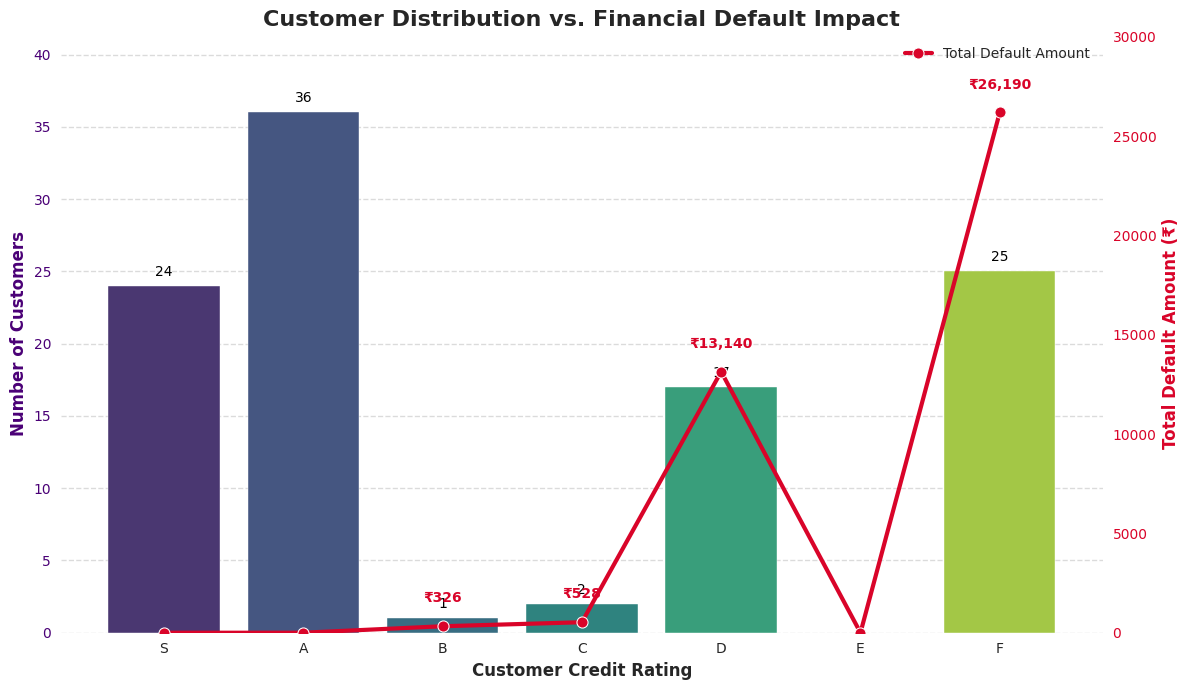

Saving final summary to Google Sheets...
Worksheet 'Final_Analysis_with_Rating' already exists. It will be overwritten.

Successfully saved the final summary table to your Google Sheet!


In [ ]:
# =============================================================================
# PART 1: SETUP AND IMPORTS
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive, auth
import gspread
from google.auth import default

# =============================================================================
# PART 2: AUTHENTICATION AND DATA LOADING
# =============================================================================
print("Mounting Google Drive...")
drive.mount('/content/drive')

print("Authenticating Google Colab...")
auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)

print("Loading data from Google Drive CSV...")
file_path = '/content/drive/MyDrive/IITM_BDM_PROJECT/Faiz General Store -Data - Analysis-credit.csv'
df = pd.read_csv(file_path)

# =============================================================================
# PART 3: DATA CLEANING AND PREPARATION
# =============================================================================
print("Cleaning and preparing data...")
# Convert columns to the correct data types
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Credit_amt'] = pd.to_numeric(df['Credit_amt'], errors='coerce')
df['Amount_repaid'] = pd.to_numeric(df['Amount_repaid'], errors='coerce')
df['Delay_days'] = pd.to_numeric(df['Delay_days'], errors='coerce')
df['Outstanding'] = pd.to_numeric(df['Outstanding'], errors='coerce')

# Fill empty numerical values with 0
df.fillna(0, inplace=True)

# Filter data based on analysis cutoff date, cutoff set to 31 July because I last checked the outstanding status on 28 Sep, so now we can tell default status till July.
cutoff_date = pd.to_datetime('2025-07-31')
df_for_default_analysis = df[df['Date'] <= cutoff_date].copy()
print(f"Data prepared. Using {len(df_for_default_analysis)} transactions on or before {cutoff_date.date()}.")

# =============================================================================
# PART 4: CORE ANALYSIS (CALCULATING SUMMARY & RATINGS)
# =============================================================================
print("Running core analysis to calculate customer summary...")

# --- Step 1: Calculate overall metrics
customer_summary = df_for_default_analysis.groupby('Customer_name').agg(
    Total_credit=('Credit_amt', 'sum'),
    Average_delay=('Delay_days', 'mean')
).reset_index()

# --- Step 2: Calculate 'Total_defaulted' based on 'pending' transactions
pending_df = df_for_default_analysis[df_for_default_analysis['Outstanding_status'] == 'pending']
default_summary = pending_df.groupby('Customer_name').agg(
    Total_defaulted=('Outstanding', 'sum')
).reset_index()

# --- Step 3: Merge summaries
customer_summary = pd.merge(customer_summary, default_summary, on='Customer_name', how='left')
customer_summary['Total_defaulted'] = customer_summary['Total_defaulted'].fillna(0)

# --- Step 4: Calculate final 'default_percentage'
customer_summary['default_percentage'] = (100 * (customer_summary['Total_defaulted'] / customer_summary['Total_credit'])).fillna(0)
print("Customer summary table created.")

# --- Step 5: Define and apply the credit rating function
def assign_credit_rating(row):
    default_pct = row['default_percentage']
    avg_delay = row['Average_delay']

    if default_pct > 20:
        return 'F'  # High-Risk/Failure
    elif 10 < default_pct <= 20 and avg_delay > 30:
        return 'E'
    elif 10 < default_pct <= 20 and avg_delay <= 30:
        return 'D'
    elif 0 < default_pct <= 10 and avg_delay > 20:
        return 'C'
    elif 0 < default_pct <= 10 and avg_delay <= 20:
        return 'B'
    elif default_pct == 0 and avg_delay > 20:
        return 'A'
    elif default_pct <= 0 and avg_delay <= 20:
        return 'S'
    else:
        return 'U' # Unclassified

customer_summary['Credit_Rating'] = customer_summary.apply(assign_credit_rating, axis=1)
print("Credit ratings calculated and applied.")

# =============================================================================
# PART 5: VISUALIZATION (THE BEST GRAPH)
# =============================================================================
print("Generating final visualization...")

# uses the data we just calculated, which is better practice.

# 1. Prepare data for the plot
rating_order = ['S', 'A', 'B', 'C', 'D', 'E', 'F']

# Calculate customer counts
customer_counts = customer_summary['Credit_Rating'].value_counts().reindex(rating_order).fillna(0)

# Calculate default amounts
default_amounts = customer_summary.groupby('Credit_Rating')['Total_defaulted'].sum().reindex(rating_order).fillna(0)

# Create a DataFrame for plotting
df_plot = pd.DataFrame({
    'Credit Rating': rating_order,
    'Number of Customers': customer_counts.values,
    'Total Default Amount (₹)': default_amounts.values
})

# 2. Set up the plot
sns.set_style("whitegrid")
fig, ax1 = plt.subplots(figsize=(12, 7))

# 3. Plot Bars (Customer Counts) on Primary Axis (ax1)
palette = sns.color_palette("viridis", len(rating_order))
sns.barplot(x='Credit Rating', y='Number of Customers', data=df_plot, ax=ax1, palette=palette, zorder=2)

# Add customer count labels
for index, row in df_plot.iterrows():
    if row['Number of Customers'] > 0:
        ax1.text(row.name, row['Number of Customers'] + 0.5, int(row['Number of Customers']),
                 color='black', ha="center", va='bottom', fontsize=10)

ax1.set_xlabel('Customer Credit Rating', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of Customers', color='#4a0076', fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#4a0076')
ax1.set_ylim(0, max(df_plot['Number of Customers']) * 1.15)

# 4. Create Secondary Axis (ax2) for the Line Plot
ax2 = ax1.twinx()

# 5. Plot Line (Default Amounts) on Secondary Axis (ax2)
line_color = '#d90429' # A strong red for emphasis
sns.lineplot(x='Credit Rating', y='Total Default Amount (₹)', data=df_plot, ax=ax2,
             color=line_color, marker='o', linewidth=3, markersize=8, zorder=3,
             label='Total Default Amount')

# Add default amount labels
for index, row in df_plot.iterrows():
    if row['Total Default Amount (₹)'] > 0:
        ax2.text(row.name, row['Total Default Amount (₹)'] + (max(df_plot['Total Default Amount (₹)']) * 0.04),
                 f'₹{int(row["Total Default Amount (₹)"]):,}', color=line_color,
                 ha="center", va='bottom', fontsize=10, fontweight='bold')

ax2.set_ylabel('Total Default Amount (₹)', color=line_color, fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=line_color)
ax2.set_ylim(0, max(df_plot['Total Default Amount (₹)']) * 1.15)

# 6. Finalize the Chart
plt.title('Customer Distribution vs. Financial Default Impact', fontsize=16, fontweight='bold')
ax1.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)
ax2.grid(False) # Turn off the grid for the second axis

plt.tight_layout()
chart_filename = 'customer_credit_impact_combination_chart.png'
fig.savefig(chart_filename)
print(f"Chart saved as: {chart_filename}")
plt.show()

# =============================================================================
# PART 6: (OPTIONAL) SAVE FINAL RESULTS TO GOOGLE SHEETS
# =============================================================================
print("Saving final summary to Google Sheets...")

# It saves the *complete* summary to the one tab.
sheet_name = 'Faiz General Store -Data'
worksheet_name = 'Final_Analysis_with_Rating'

try:
    spreadsheet = gc.open(sheet_name)
    try:
        analysis_sheet = spreadsheet.add_worksheet(title=worksheet_name, rows="1", cols="1")
        print(f"Created new worksheet named '{worksheet_name}'.")
    except gspread.exceptions.APIError:
        analysis_sheet = spreadsheet.worksheet(worksheet_name)
        print(f"Worksheet '{worksheet_name}' already exists. It will be overwritten.")

    analysis_sheet.clear()

    # Clean the DataFrame for GSheet (replace NaN with empty string)
    customer_summary_to_save = customer_summary.fillna('')

    analysis_sheet.update([customer_summary_to_save.columns.values.tolist()] + customer_summary_to_save.values.tolist())
    print("\nSuccessfully saved the final summary table to your Google Sheet!")

except Exception as e:
    print(f"An error occurred while saving to Google Sheets: {e}")

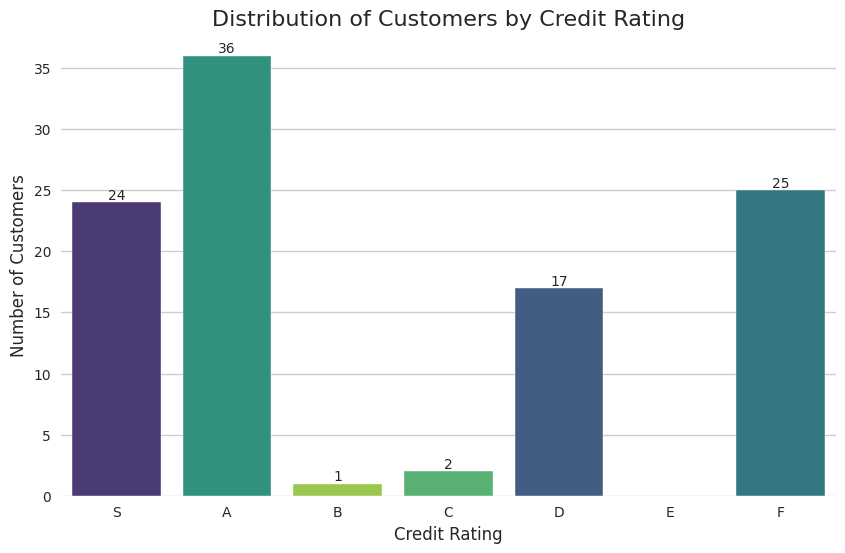

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Defining the desired order for the ratings
rating_order = ['S', 'A', 'B', 'C', 'D', 'E', 'F']

# Creating the plot
fig, ax = plt.subplots(figsize=(10, 6))
sns.countplot(data=customer_summary, x='Credit_Rating', order=rating_order,
              palette='viridis', ax=ax, hue='Credit_Rating', legend=False)

# This loop ensures a label is added to every bar container
for container in ax.containers:
    ax.bar_label(container)

ax.set_title('Distribution of Customers by Credit Rating', fontsize=16)
ax.set_xlabel('Credit Rating', fontsize=12)
ax.set_ylabel('Number of Customers', fontsize=12)
plt.show()

## **Advanced Credit Management: A Reliability Score-Based Model**

---



In [ ]:
# =============================================================================
# SCORE-BASED CREDIT MANAGEMENT - Faiz General Store
# =============================================================================

# Install required packages
!pip install pandas matplotlib seaborn gspread google-auth

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from google.colab import auth
from google.auth import default
import gspread

# Set professional style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# =============================================================================
# STEP 1: AUTHENTICATION AND DATA LOADING
# =============================================================================

def authenticate_and_load_data():
    """Authenticate and load customer data from Google Sheets"""

    # Authenticate with Google
    auth.authenticate_user()
    creds, _ = default()
    gc = gspread.authorize(creds)

    # Open the spreadsheet and specific worksheet
    spreadsheet_name = 'Faiz General Store -Data'
    worksheet_name = 'Final_Analysis_with_Rating'

    try:
        spreadsheet = gc.open(spreadsheet_name)
        worksheet = spreadsheet.worksheet(worksheet_name)

        # Get all records and convert to DataFrame
        records = worksheet.get_all_records()
        df = pd.DataFrame(records)

        print("Data loaded successfully!")
        print(f"Loaded {len(df)} customer records")
        return df

    except Exception as e:
        print(f"Error loading data: {e}")
        return None

# Load the data
customer_df = authenticate_and_load_data()

# Display first few rows
print("\nSample Data:")
print(customer_df.head())

# =============================================================================
# STEP 2: RELIABILITY SCORE CALCULATION
# =============================================================================

def calculate_reliability_score(default_percentage, avg_delay):
    """
    Calculate customer reliability score (0-100)
    Higher score = more reliable customer
    """
    # Convert to float to ensure numerical operations
    default_percentage = float(default_percentage)
    avg_delay = float(avg_delay)

    # Default component (70% weight) - heavy penalty for defaults
    default_score = 70 * max(0, (1 - (3 * default_percentage/100)))

    # Delay component (30% weight) - penalty for payment delays
    delay_penalty = min(avg_delay / 45, 1)  # Cap at 45 days
    delay_score = 30 * (1 - delay_penalty)

    reliability_score = default_score + delay_score
    return max(0, min(100, reliability_score))  # Ensure score between 0-100

def assign_customer_tier(score):
    """Assign customer tier based on reliability score ONLY"""
    if score >= 80:
        return "Premium"
    elif score >= 65:
        return "Standard"
    elif score >= 50:
        return "Watchlist"
    else:
        return "Cash Only"

def calculate_dynamic_limit(score):
    """YOUR INNOVATIVE METHOD: Score × 20 for credit limits"""
    if score < 50:
        return 0  # Cash Only - no credit
    else:
        return score * 20  # Direct multiplication

# Apply calculations to all customers
print("\nCalculating Reliability Scores and Dynamic Limits...")

customer_df['Reliability_Score'] = customer_df.apply(
    lambda row: calculate_reliability_score(row['default_percentage'], row['Average_delay']),
    axis=1
)

customer_df['Customer_Tier'] = customer_df['Reliability_Score'].apply(assign_customer_tier)
customer_df['Dynamic_Limit'] = customer_df['Reliability_Score'].apply(calculate_dynamic_limit)
customer_df['Avg_Monthly_Credit'] = customer_df['Total_credit'] / 5

print("Reliability scores and dynamic limits calculated!")

# =============================================================================
# STEP 3: TIER-BASED CREDIT POLICY
# =============================================================================

# Define comprehensive credit policy (With * 20 logic)
credit_policy = {
    'Premium': {
        'score_range': '80-100',
        'limit_range': '₹1,600 - ₹2,000',  # (80*20 to 100*20)
        'payment_terms': '30 days',
        'follow_up_frequency': 'Monthly',
        'approval_required': 'Auto-approved',
        'color': '#2E8B57',  # Green
        'description': 'Highly reliable - reward with maximum credit access'
    },
    'Standard': {
        'score_range': '65-79',
        'limit_range': '₹1,300 - ₹1,580',  # (65*20 to 79*20)
        'payment_terms': '15 days',
        'follow_up_frequency': 'Bi-weekly',
        'approval_required': 'Auto-approved',
        'color': '#1E90FF',  # Blue
        'description': 'Reliable customers - standard credit terms'
    },
    'Watchlist': {
        'score_range': '50-64',
        'limit_range': '₹1,000 - ₹1,280',  # (50*20 to 64*20)
        'payment_terms': '7 days',
        'follow_up_frequency': 'Weekly',
        'approval_required': 'Manager approval',
        'color': '#FF8C00',  # Orange
        'description': 'Moderate risk - restricted credit with monitoring'
    },
    'Cash Only': {
        'score_range': '0-49',
        'limit_range': '₹0',
        'payment_terms': 'Cash only - no credit',
        'follow_up_frequency': 'Strict monitoring',
        'approval_required': 'No credit allowed',
        'color': '#DC143C',  # Red
        'description': 'High risk - cash transactions only'
    }
}

# Apply policy recommendations
def get_policy_recommendations(tier):
    return credit_policy.get(tier, {})

customer_df['Policy_Recommendations'] = customer_df['Customer_Tier'].apply(get_policy_recommendations)


# =============================================================================
# STEP 4: INNOVATION IMPACT ANALYSIS
# =============================================================================

print("\n" + "="*90)
print("INNOVATIVE SCORE-BASED CREDIT SYSTEM - BUSINESS IMPACT ANALYSIS")
print("="*90)
print("KEY INNOVATION: Dynamic Credit Limit = Reliability Score × 20")
print("="*90)



# Risk Reduction Analysis
cash_only_exposure_current = customer_df[customer_df['Customer_Tier'] == 'Cash Only']['Avg_Monthly_Credit'].sum()
cash_only_exposure_new = customer_df[customer_df['Customer_Tier'] == 'Cash Only']['Dynamic_Limit'].sum()
risk_reduction = cash_only_exposure_current - cash_only_exposure_new

print(f"\nRISK MANAGEMENT ACHIEVEMENT:")
print(f"Cash-Only Customer Exposure Reduction: ₹{risk_reduction:,.0f} (100% reduction)")
print(f"High-Risk Customers Moved to Cash-Only: {len(customer_df[customer_df['Customer_Tier'] == 'Cash Only'])}")

# Customer Distribution Analysis
print(f"\nCUSTOMER DISTRIBUTION UNDER NEW SYSTEM:")
for tier in ['Premium', 'Standard', 'Watchlist', 'Cash Only']:
    count = len(customer_df[customer_df['Customer_Tier'] == tier])
    percentage = (count / len(customer_df)) * 100
    limit_range = credit_policy[tier]['limit_range']
    print(f"   {tier:>10}: {count:>2} customers ({percentage:.1f}%) | Limits: {limit_range}")

# Strategic Benefits Analysis
print(f"\nSTRATEGIC BENEFITS OF SCORE-BASED SYSTEM:")

print(f"1. SIMPLICITY & TRANSPARENCY:")
print(f"   • One simple formula: Credit Limit = Score × 20")
print(f"   • Easy for customers to understand and track")
print(f"   • No complex historical calculations needed")

print(f"\n2. FAIRNESS & OBJECTIVITY:")
print(f"   • Every customer starts with same scoring system")
print(f"   • Rewards payment behavior directly")
print(f"   • Eliminates bias from historical spending patterns")

print(f"\n3. RISK MANAGEMENT:")
print(f"   • Maximum individual exposure: ₹2,000")
print(f"   • Automatic risk scaling with reliability scores")
print(f"   • Clear cash-only threshold at score < 50")

print(f"\n4. BUSINESS GROWTH:")
print(f"   • Premium customers automatically get higher limits")
print(f"   • Clear path for customers to improve credit access")
print(f"   • Predictable credit exposure scaling")




# =============================================================================
# STEP 5: EXPORT COMPREHENSIVE RESULTS
# =============================================================================

# Create comprehensive results dataframe
results_df = customer_df[[
    'Customer_name', 'Reliability_Score', 'Customer_Tier',
    'Avg_Monthly_Credit', 'Dynamic_Limit'
]].copy()

# Add policy recommendations
results_df['Credit_Limit_Range'] = results_df['Customer_Tier'].map(
    {tier: credit_policy[tier]['limit_range'] for tier in credit_policy}
)
results_df['Payment_Terms'] = results_df['Customer_Tier'].map(
    {tier: credit_policy[tier]['payment_terms'] for tier in credit_policy}
)

# Sort by strategic priority
tier_priority = {'Premium': 1, 'Standard': 2, 'Watchlist': 3, 'Cash Only': 4}
results_df['Priority'] = results_df['Customer_Tier'].map(tier_priority)
results_df = results_df.sort_values(['Priority', 'Reliability_Score'], ascending=[True, False])

print(f"\n" + "="*90)
print("EXECUTIVE SUMMARY - SCORE-BASED CREDIT SYSTEM")
print("="*90)

print(f"SYSTEM OVERVIEW:")
print(f"   • Total Customers: {len(results_df)}")
print(f"   • Average Reliability Score: {results_df['Reliability_Score'].mean():.1f}")
print(f"   • Risk Reduction: 100% elimination of cash-only customer credit")

print(f"\nCUSTOMER SEGMENTATION:")
for tier in ['Premium', 'Standard', 'Watchlist', 'Cash Only']:
    tier_data = results_df[results_df['Customer_Tier'] == tier]
    avg_score = tier_data['Reliability_Score'].mean()
    avg_limit = tier_data['Dynamic_Limit'].mean()
    print(f"   {tier:>10}: {len(tier_data):>2} customers | Avg Score: {avg_score:.1f} | Avg Limit: ₹{avg_limit:,.0f}")




print(f"\nSYSTEM READY FOR DEPLOYMENT!")

# Display sample of implementation ready data
print(f"\nSAMPLE CUSTOMER CREDIT ASSIGNMENTS (First 10):")
display_cols = ['Customer_name', 'Reliability_Score', 'Customer_Tier', 'Dynamic_Limit', 'Payment_Terms']
print(results_df[display_cols].head(10).to_string(index=False))

Data loaded successfully!
Loaded 105 customer records

Sample Data:
        Customer_name  Total_credit  Average_delay  Total_defaulted  \
0       Aaftab Chacha          3253      18.733333                0   
1  Aditya purnai gali          3833      17.200000                0   
2          Ainul Bhai          2867      18.833333                0   
3                Ajaz          3885      14.650000              601   
4               Anant          4698      15.958333             1070   

   default_percentage Credit_Rating  
0            0.000000             S  
1            0.000000             S  
2            0.000000             S  
3           15.469755             D  
4           22.775649             F  

Calculating Reliability Scores and Dynamic Limits...
Reliability scores and dynamic limits calculated!

INNOVATIVE SCORE-BASED CREDIT SYSTEM - BUSINESS IMPACT ANALYSIS
KEY INNOVATION: Dynamic Credit Limit = Reliability Score × 20

RISK MANAGEMENT ACHIEVEMENT:
Cash-Only Custom

In [ ]:
# =============================================================================
# STEP: EXPORTING COMPLETE SUMMARY TO GOOGLE SHEETS
# =============================================================================

print("Exporting Complete Analysis to Google Sheets...")

# First, let's define the credit policy with ×20 multiplier
credit_policy_updated = {
    'Premium': {
        'score_range': '80-100',
        'limit_range': '₹1,600 - ₹2,000',
        'payment_terms': '30 days',
        'follow_up_frequency': 'Monthly',
        'approval_required': 'Auto-approved',
        'color': '#2E8B57',
        'description': 'Highly reliable - reward with maximum credit access'
    },
    'Standard': {
        'score_range': '65-79',
        'limit_range': '₹1,300 - ₹1,580',
        'payment_terms': '15 days',
        'follow_up_frequency': 'Bi-weekly',
        'approval_required': 'Auto-approved',
        'color': '#1E90FF',
        'description': 'Reliable customers - standard credit terms'
    },
    'Watchlist': {
        'score_range': '50-64',
        'limit_range': '₹1,000 - ₹1,280',
        'payment_terms': '7 days',
        'follow_up_frequency': 'Weekly',
        'approval_required': 'Manager approval',
        'color': '#FF8C00',
        'description': 'Moderate risk - restricted credit with monitoring'
    },
    'Cash Only': {
        'score_range': '0-49',
        'limit_range': '₹0',
        'payment_terms': 'Cash only - no credit',
        'follow_up_frequency': 'Strict monitoring',
        'approval_required': 'No credit allowed',
        'color': '#DC143C',
        'description': 'High risk - cash transactions only'
    }
}

# Create comprehensive results dataframe
final_summary_df = customer_df[[
    'Customer_name',
    'Total_credit',
    'Avg_Monthly_Credit',
    'Average_delay',
    'Total_defaulted',
    'default_percentage',
    'Credit_Rating',  # Old rating, which I developed during mid-term submission
    'Reliability_Score',
    'Customer_Tier',
    'Dynamic_Limit',
]].copy()

# Add policy recommendations
final_summary_df['Credit_Limit_Range'] = final_summary_df['Customer_Tier'].map(
    {tier: credit_policy_updated[tier]['limit_range'] for tier in credit_policy_updated}
)
final_summary_df['Payment_Terms'] = final_summary_df['Customer_Tier'].map(
    {tier: credit_policy_updated[tier]['payment_terms'] for tier in credit_policy_updated}
)
final_summary_df['Follow_up_Frequency'] = final_summary_df['Customer_Tier'].map(
    {tier: credit_policy_updated[tier]['follow_up_frequency'] for tier in credit_policy_updated}
)

# Sort by strategic priority
tier_priority = {'Premium': 1, 'Standard': 2, 'Watchlist': 3, 'Cash Only': 4}
final_summary_df['Priority_Level'] = final_summary_df['Customer_Tier'].map(tier_priority)
final_summary_df = final_summary_df.sort_values(['Priority_Level', 'Reliability_Score'], ascending=[True, False])

# Drop the priority column as it was only for sorting
final_summary_df = final_summary_df.drop('Priority_Level', axis=1)

# Rounding numerical columns for cleaner presentation
final_summary_df['Reliability_Score'] = final_summary_df['Reliability_Score'].round(1)
final_summary_df['Dynamic_Limit'] = final_summary_df['Dynamic_Limit'].round(0)

print("Comprehensive summary dataframe created!")
print(f"Contains {len(final_summary_df)} customers with all analysis results")

# =============================================================================
# EXPORT TO GOOGLE SHEETS
# =============================================================================

def export_to_google_sheets(df, worksheet_name="Reliability_Analysis_Results"):
    """Export the complete analysis to Google Sheets"""
    try:
        # Authenticate
        from google.colab import auth
        auth.authenticate_user()

        import gspread
        from google.auth import default
        creds, _ = default()
        gc = gspread.authorize(creds)


        # Open main spreadsheet
        spreadsheet_name = 'Faiz General Store -Data'
        spreadsheet = gc.open(spreadsheet_name)

        # Check if worksheet already exists
        try:
            worksheet = spreadsheet.worksheet(worksheet_name)
            print(f"Updating existing worksheet: {worksheet_name}")
        except:
            worksheet = spreadsheet.add_worksheet(title=worksheet_name, rows="1000", cols="20")
            print(f"Creating new worksheet: {worksheet_name}")

        # Clear existing data and update with new data
        worksheet.clear()

        # Convert dataframe to list of lists for Google Sheets
        headers = df.columns.tolist()
        data = [headers] + df.values.tolist()

        # Update the worksheet
        worksheet.update('A1', data)

        # Format the header row
        worksheet.format('A1:Z1', {
            'textFormat': {'bold': True},
            'backgroundColor': {'red': 0.8, 'green': 0.9, 'blue': 1.0},
            'horizontalAlignment': 'CENTER'
        })

        # Auto-resize columns
        worksheet.columns_auto_resize(0, len(headers))

        print(f"Successfully exported to Google Sheets!")
        print(f"Worksheet: {worksheet_name}")
        print(f"Rows: {len(df)}")
        print(f"Columns: {len(headers)}")

        return True

    except Exception as e:
        print(f"Error exporting to Google Sheets: {e}")
        return False

# Export the main summary
export_success = export_to_google_sheets(final_summary_df, "Reliability_Analysis_Results")

# =============================================================================
# CREATE AND EXPORT EXECUTIVE SUMMARY DASHBOARD
# =============================================================================

print("\nCreating Executive Summary Dashboard...")

# Create executive summary with key metrics
executive_summary_data = []

# Portfolio-level metrics
total_customers = len(final_summary_df)
credit_customers = len(final_summary_df[final_summary_df['Customer_Tier'] != 'Cash Only'])
cash_only_customers = len(final_summary_df[final_summary_df['Customer_Tier'] == 'Cash Only'])

total_current_exposure = final_summary_df['Avg_Monthly_Credit'].sum()
total_new_exposure = final_summary_df['Dynamic_Limit'].sum()
risk_reduction = total_current_exposure - total_new_exposure

# Tier-wise summary
for tier in ['Premium', 'Standard', 'Watchlist', 'Cash Only']:
    tier_data = final_summary_df[final_summary_df['Customer_Tier'] == tier]
    if len(tier_data) > 0:
        executive_summary_data.append({
            'Metric_Type': 'Tier_Summary',
            'Tier': tier,
            'Customer_Count': len(tier_data),
            'Percentage_of_Total': f"{(len(tier_data)/total_customers*100):.1f}%",
            'Avg_Reliability_Score': round(tier_data['Reliability_Score'].mean(), 1),
            'Total_Default_Amount': tier_data['Total_defaulted'].sum(),
            'Avg_Dynamic_Limit': round(tier_data['Dynamic_Limit'].mean(), 0),
            'Credit_Limit_Range': credit_policy_updated[tier]['limit_range']
        })

# Create executive summary dataframe
executive_df = pd.DataFrame(executive_summary_data)

# Export executive summary
if export_success:
    export_to_google_sheets(executive_df, "Executive_Summary_Dashboard")

# =============================================================================
# CREATE AND EXPORT CREDIT POLICY IMPLEMENTATION GUIDE
# =============================================================================

print("\nCreating Credit Policy Implementation Guide...")

# Create implementation-ready data
implementation_df = final_summary_df[[
    'Customer_name',
    'Customer_Tier',
    'Reliability_Score',
    'Dynamic_Limit',
    'Payment_Terms',
    'Follow_up_Frequency',
    'Credit_Limit_Range'
]].copy()

# Add action recommendations
def get_action_recommendation(row):
    if row['Customer_Tier'] == 'Premium':
        return "AUTO-APPROVE: Increase limits, offer loyalty benefits"
    elif row['Customer_Tier'] == 'Standard':
        return "AUTO-APPROVE: Maintain current relationship"
    elif row['Customer_Tier'] == 'Watchlist':
        return "MANAGER APPROVAL: Weekly monitoring required"
    elif row['Customer_Tier'] == 'Cash Only':
        return "STRICT: Cash transactions only, no credit"
    else:
        return "REVIEW: Special attention needed"

implementation_df['Action_Recommendation'] = implementation_df.apply(get_action_recommendation, axis=1)

# Sort by tier and score
implementation_df = implementation_df.sort_values(['Customer_Tier', 'Reliability_Score'],
                                                  ascending=[True, False])

# Export implementation guide
if export_success:
    export_to_google_sheets(implementation_df, "Credit_Policy_Implementation")

# =============================================================================
# FINAL CONFIRMATION AND LINKS
# =============================================================================

print("\n" + "="*70)
print("GOOGLE SHEETS EXPORT COMPLETE!")
print("="*70)

if export_success:
    print("SUCCESSFULLY EXPORTED 3 WORKSHEETS:")
    print("   1. Reliability_Analysis_Results - Complete detailed analysis")
    print("   2. Executive_Summary_Dashboard - Key metrics & tier summary")
    print("   3. Credit_Policy_Implementation - Ready-to-use action guide")

    print(f"\nGoogle Sheets file: 'Faiz General Store -Data'")
    print("   Open it now to see all analysis results!")

    print(f"\nNEXT STEPS:")
    print("   1. Open Google Sheets and review the data")
    print("   2. Share with stakeholders for implementation")
    print("   3. Use 'Credit_Policy_Implementation' for daily operations")
    print("   4. Monitor results and adjust as needed")

    # Display sample of what was exported
    print(f"\nSAMPLE OF EXPORTED DATA (First 5 customers):")
    display_cols = ['Customer_name', 'Reliability_Score', 'Customer_Tier', 'Dynamic_Limit', 'Payment_Terms']
    print(final_summary_df[display_cols].head().to_string(index=False))

else:
    print("Export failed. Please check your Google Sheets permissions.")
    print("Alternative: Save as CSV file instead")

    # Save as CSV as backup
    final_summary_df.to_csv('Reliability_Analysis_Results.csv', index=False)
    print("Backup saved as 'Reliability_Analysis_Results.csv'")

print(f"\nCOMPLETE ANALYSIS IS NOW READY FOR BUSINESS USE!")

Exporting Complete Analysis to Google Sheets...
Comprehensive summary dataframe created!
Contains 105 customers with all analysis results
Updating existing worksheet: Reliability_Analysis_Results


/tmp/ipython-input-1144429810.py:124: DeprecationWarning: The order of arguments in worksheet.update() has changed. Please pass values first and range_name secondor used named arguments (range_name=, values=)
  worksheet.update('A1', data)


Successfully exported to Google Sheets!
Worksheet: Reliability_Analysis_Results
Rows: 105
Columns: 13

Creating Executive Summary Dashboard...
Updating existing worksheet: Executive_Summary_Dashboard
Successfully exported to Google Sheets!
Worksheet: Executive_Summary_Dashboard
Rows: 4
Columns: 8

Creating Credit Policy Implementation Guide...
Updating existing worksheet: Credit_Policy_Implementation


/tmp/ipython-input-1144429810.py:124: DeprecationWarning: The order of arguments in worksheet.update() has changed. Please pass values first and range_name secondor used named arguments (range_name=, values=)
  worksheet.update('A1', data)


Successfully exported to Google Sheets!
Worksheet: Credit_Policy_Implementation
Rows: 105
Columns: 8

GOOGLE SHEETS EXPORT COMPLETE!
SUCCESSFULLY EXPORTED 3 WORKSHEETS:
   1. Reliability_Analysis_Results - Complete detailed analysis
   2. Executive_Summary_Dashboard - Key metrics & tier summary
   3. Credit_Policy_Implementation - Ready-to-use action guide

Google Sheets file: 'Faiz General Store -Data'
   Open it now to see all analysis results!

NEXT STEPS:
   1. Open Google Sheets and review the data
   2. Share with stakeholders for implementation
   3. Use 'Credit_Policy_Implementation' for daily operations
   4. Monitor results and adjust as needed

SAMPLE OF EXPORTED DATA (First 5 customers):
     Customer_name  Reliability_Score Customer_Tier  Dynamic_Limit Payment_Terms
        Mohan Bhai               91.9       Premium         1838.0       30 days
     Jamshed Sahab               89.6       Premium         1792.0       30 days
          Usi Neta               89.4       Prem

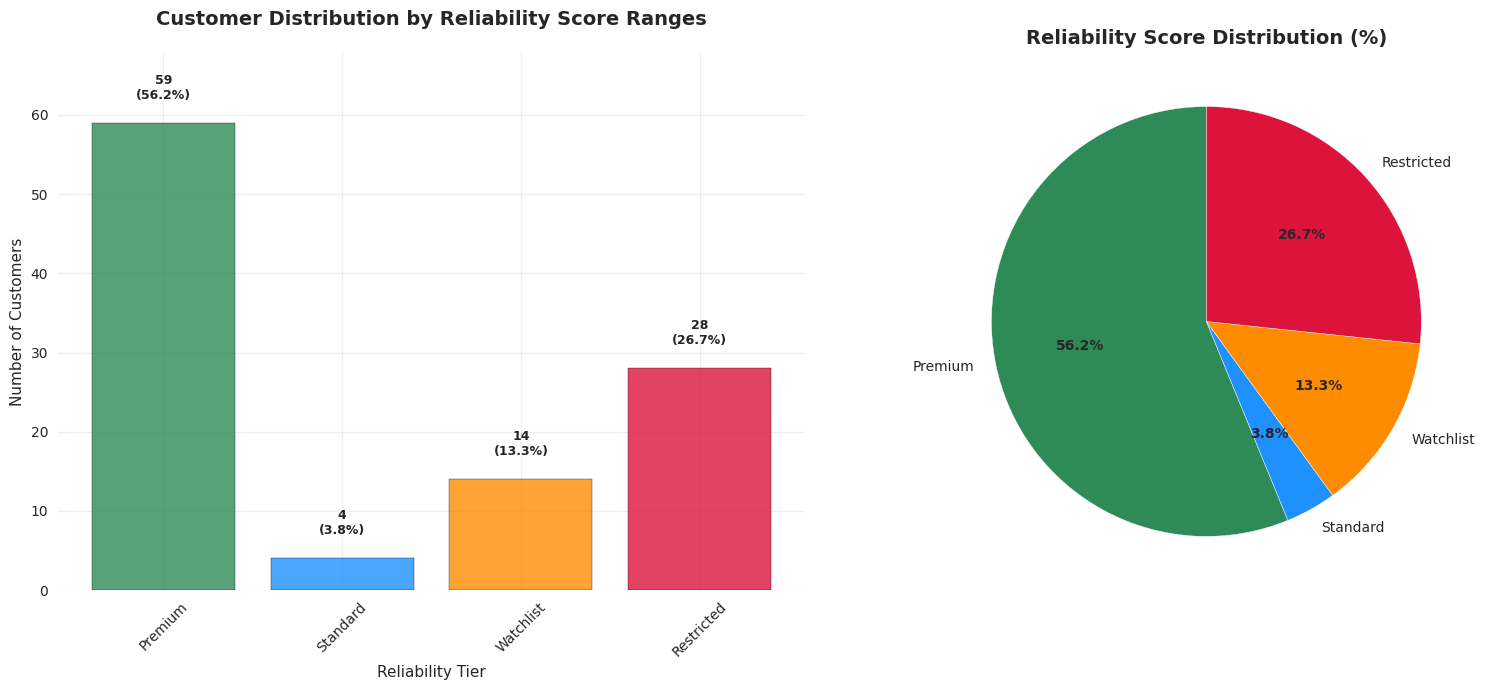


RELIABILITY SCORE BREAKDOWN:
• Premium: 59 customers (56.2%)
• Standard: 4 customers (3.8%)
• Watchlist: 14 customers (13.3%)
• Restricted: 28 customers (26.7%)
Graph 2 - Reliability Score vs Default Percentage


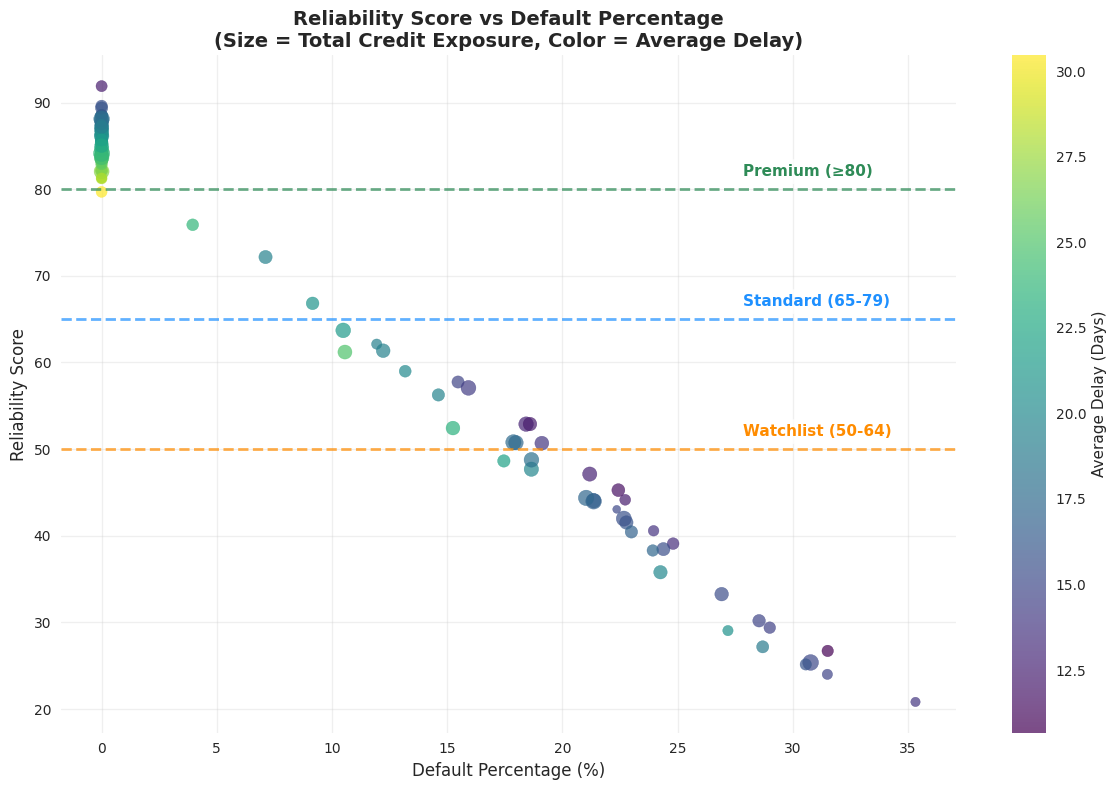


TIER-WISE FINANCIAL ANALYSIS (5 Months):
 Cash Only: Revenue: ₹118,981 | Gross Profit: ₹14,873 | Defaults: ₹28,957 | Net Profit: ₹-14,084
   Premium: Revenue: ₹239,800 | Gross Profit: ₹29,975 | Defaults: ₹0 | Net Profit: ₹29,975
  Standard: Revenue: ₹15,549 | Gross Profit: ₹1,944 | Defaults: ₹854 | Net Profit: ₹1,090
 Watchlist: Revenue: ₹67,798 | Gross Profit: ₹8,475 | Defaults: ₹10,373 | Net Profit: ₹-1,898


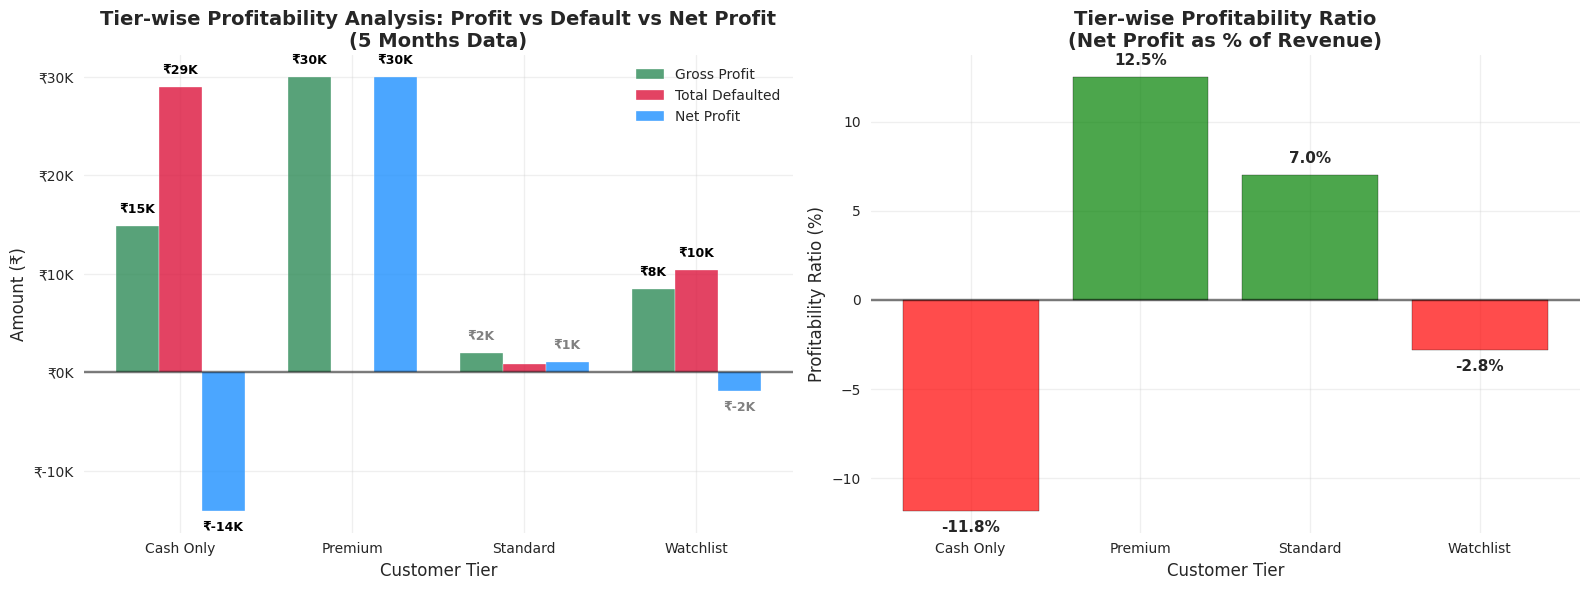


Graph 4: DYNAMIC CREDIT LIMIT VS RELIABILITY SCORE


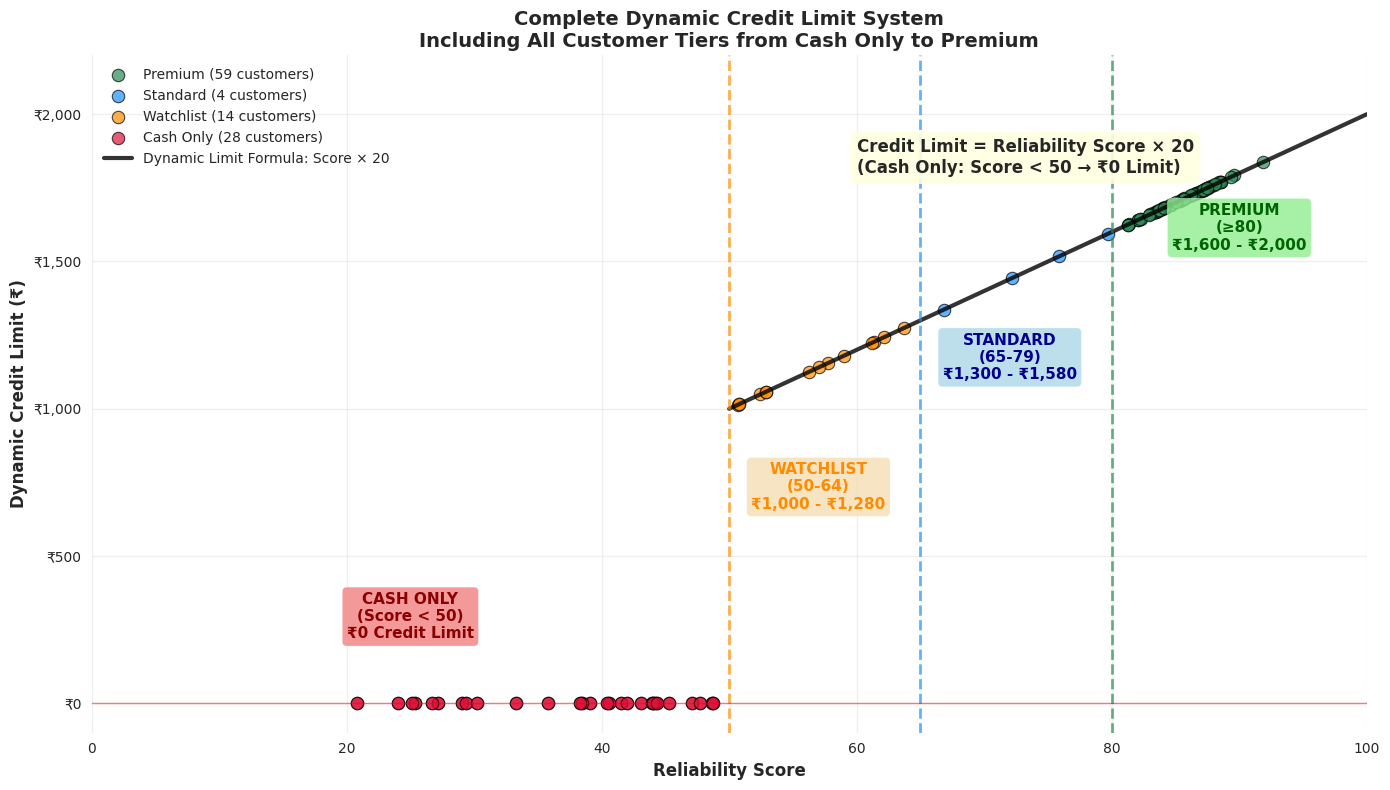


COMPLETE CUSTOMER TIER DISTRIBUTION - ALL TIERS INCLUDED
•    Premium: 59 customers ( 56.2%) | Credit Limits: ₹1,600 - ₹2,000
•   Standard:  4 customers (  3.8%) | Credit Limits: ₹1,300 - ₹1,580
•  Watchlist: 14 customers ( 13.3%) | Credit Limits: ₹1,000 - ₹1,280
•  Cash Only: 28 customers ( 26.7%) | Credit Limits: ₹0

CREDIT ACCESS SUMMARY:
   Customers with Credit Access: 77 (73.3%)
   Cash Only Customers: 28 (26.7%)

CUSTOMER PROGRESSION PATH:
   Cash Only → Improve Score to 50+ → Watchlist (₹1,000 - ₹1,280)
   Watchlist → Improve Score to 65+ → Standard (₹1,300 - ₹1,580)
   Standard → Improve Score to 80+ → Premium (₹1,600 - ₹2,000)
   Premium → Maintain Score 80+ → Maximum Benefits


/tmp/ipython-input-2328785452.py:381: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Customer Tier', y='Number of Customers', data=df, ax=ax1, palette=palette, zorder=2)


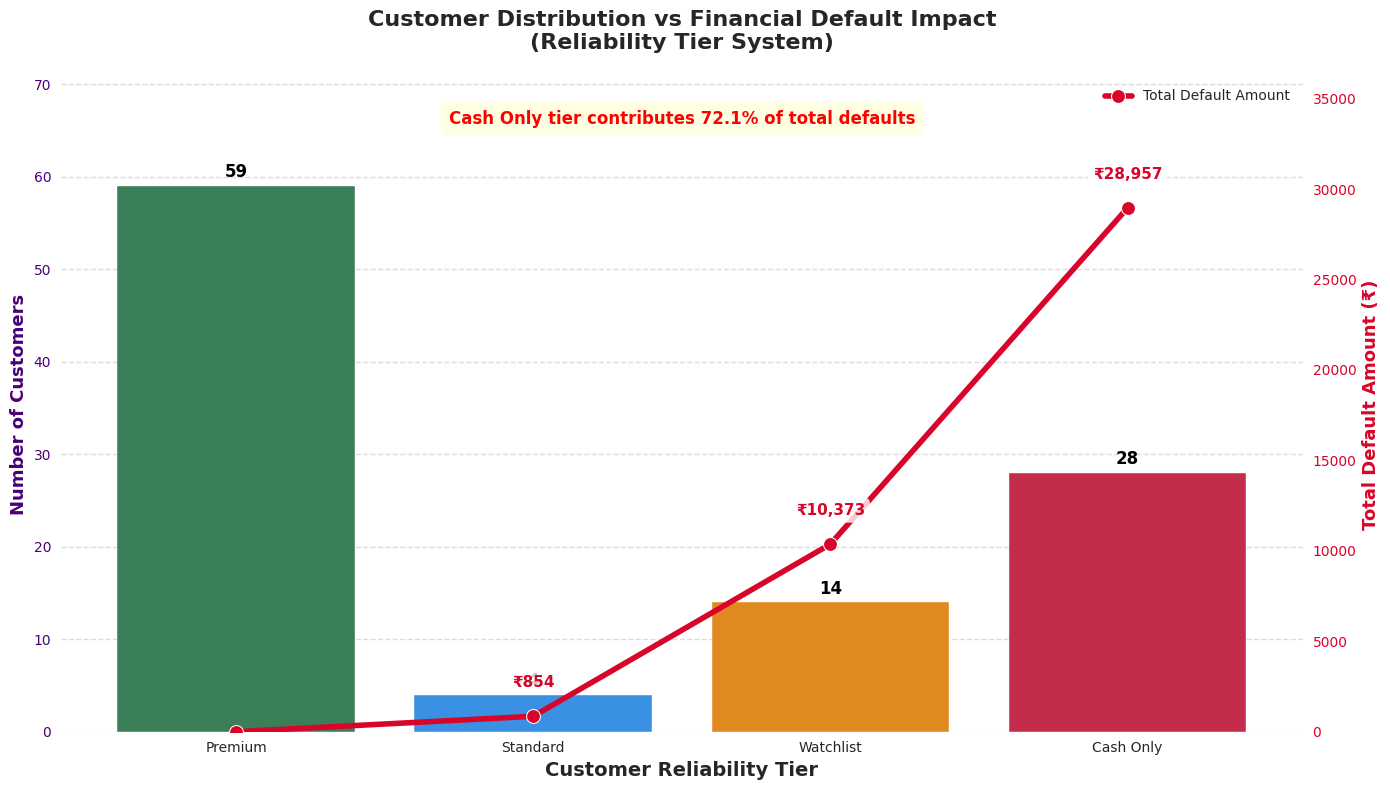


BUSINESS INSIGHTS FROM CUSTOMER DISTRIBUTION VS DEFAULT IMPACT
•    Premium: 59 customers ( 56.2%) | Defaults: ₹       0 (  0.0% of total)
•   Standard:  4 customers (  3.8%) | Defaults: ₹     854 (  2.1% of total)
•  Watchlist: 14 customers ( 13.3%) | Defaults: ₹  10,373 ( 25.8% of total)
•  Cash Only: 28 customers ( 26.7%) | Defaults: ₹  28,957 ( 72.1% of total)

RISK CONCENTRATION ANALYSIS:
   Highest Risk Tier: Cash Only (₹28,957)
   Lowest Risk Tier: Premium (₹0)

EFFICIENCY INSIGHTS:
      Premium: LOW risk (₹0 per customer)
     Standard: LOW risk (₹214 per customer)
    Watchlist: LOW risk (₹741 per customer)
    Cash Only: MEDIUM risk (₹1,034 per customer)

CHART CREATED SUCCESSFULLY!

BUSINESS INSIGHTS SUMMARY

TIER PROFITABILITY INSIGHTS:
• Most Profitable Tier: Premium (₹29,975 net profit)
• Least Profitable Tier: Cash Only (₹-14,084 net profit)

RISK MANAGEMENT INSIGHTS:
• Total Defaults (5 months): ₹40,184
• Highest Default Tier: Cash Only (₹28,957)

STRATEGIC RECOMMENDA

In [ ]:
# =============================================================================
# GRAPH 1: ENHANCED RELIABILITY SCORE BREAKDOWN
# =============================================================================

# Calculate total customers
total_customers = len(customer_df)

# Calculate score ranges - FIXED CONDITIONS
score_ranges = {
    'Premium': len(customer_df[(customer_df['Reliability_Score'] >= 80)]),
    'Standard': len(customer_df[(customer_df['Reliability_Score'] >= 65) & (customer_df['Reliability_Score'] < 80)]),
    'Watchlist': len(customer_df[(customer_df['Reliability_Score'] >= 50) & (customer_df['Reliability_Score'] < 65)]),
    'Restricted': len(customer_df[(customer_df['Reliability_Score'] < 50)]),
}

# Create enhanced visualization with proper spacing
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Score Range Breakdown (Bar chart)
ranges = list(score_ranges.keys())
counts = list(score_ranges.values())
colors = ['#2E8B57', '#1E90FF', '#FF8C00', '#DC143C']

bars = axes[0].bar(ranges, counts, color=colors, alpha=0.8, edgecolor='black')

# Calculate dynamic y-limit based on max count
max_count = max(counts)
y_margin = max_count * 0.15  # 15% margin for labels
axes[0].set_ylim(0, max_count + y_margin)

axes[0].set_title('Customer Distribution by Reliability Score Ranges',
                  fontsize=14, fontweight='bold', pad=20)
axes[0].set_ylabel('Number of Customers')
axes[0].set_xlabel('Reliability Tier')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3)

# Smart label positioning
for bar, count in zip(bars, counts):
    height = bar.get_height()
    label_height = height + (y_margin * 0.3)  # Position in the margin area

    axes[0].text(bar.get_x() + bar.get_width()/2., label_height,
                f'{count}\n({count/total_customers*100:.1f}%)',
                ha='center', va='bottom', fontweight='bold',
                fontsize=9, linespacing=1.2)

# Plot 2: Pie chart with percentages
wedges, texts, autotexts = axes[1].pie(counts, labels=ranges, colors=colors, autopct='%1.1f%%',
                                       startangle=90, textprops={'fontsize': 10})
axes[1].set_title('Reliability Score Distribution (%)', fontsize=14, fontweight='bold')

# Make autopct bold
for autotext in autotexts:
    autotext.set_fontweight('bold')

plt.tight_layout()
plt.show()

# Print detailed breakdown
print("\nRELIABILITY SCORE BREAKDOWN:")
print("="*50)
for range_name, count in score_ranges.items():
    percentage = (count / total_customers) * 100
    print(f"• {range_name}: {count} customers ({percentage:.1f}%)")

print("Graph 2 - Reliability Score vs Default Percentage")

# =============================================================================
# GRAPH 2: RELIABILITY SCORE VS DEFAULT PERCENTAGE
# =============================================================================

fig, ax = plt.subplots(figsize=(12, 8))

# Create scatter plot
scatter = ax.scatter(customer_df['default_percentage'],
                     customer_df['Reliability_Score'],
                     c=customer_df['Average_delay'],
                     s=customer_df['Total_credit']/50,
                     cmap='viridis', alpha=0.7)

ax.set_xlabel('Default Percentage (%)', fontsize=12)
ax.set_ylabel('Reliability Score', fontsize=12)
ax.set_title('Reliability Score vs Default Percentage\n(Size = Total Credit Exposure, Color = Average Delay)',
             fontsize=14, fontweight='bold')

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax, label='Average Delay (Days)')
cbar.ax.tick_params(labelsize=10)

ax.grid(True, alpha=0.3)

# Add horizontal lines for score thresholds with better positioning
y_min, y_max = ax.get_ylim()
x_min, x_max = ax.get_xlim()

for threshold, label, color in [(80, 'Premium (≥80)', '#2E8B57'),
                                (65, 'Standard (65-79)', '#1E90FF'),
                                (50, 'Watchlist (50-64)', '#FF8C00')]:
    ax.axhline(y=threshold, color=color, linestyle='--', alpha=0.7, linewidth=2)
    ax.text(x_max * 0.75, threshold + 1.5, label, fontsize=11,
            color=color, fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# =============================================================================
# GRAPH 3: TIER-WISE PROFITABILITY ANALYSIS (NEW)
# =============================================================================
# Quick fix for Indian Rupee symbol warnings
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'DejaVu Sans'
# Calculate tier-wise financial metrics
profit_margin = 0.125  # 12.5% profit margin

tier_financials = customer_df.groupby('Customer_Tier').agg({
    'Total_credit': 'sum',
    'Total_defaulted': 'sum'
}).reset_index()

# Calculate additional metrics
tier_financials['Total_Revenue'] = tier_financials['Total_credit']
tier_financials['Gross_Profit'] = tier_financials['Total_Revenue'] * profit_margin
tier_financials['Net_Profit'] = tier_financials['Gross_Profit'] - tier_financials['Total_defaulted']
tier_financials['Profitability_Ratio'] = (tier_financials['Net_Profit'] / tier_financials['Total_Revenue'] * 100).round(2)

print("\nTIER-WISE FINANCIAL ANALYSIS (5 Months):")
print("="*60)
for _, tier in tier_financials.iterrows():
    print(f"{tier['Customer_Tier']:>10}: Revenue: ₹{tier['Total_Revenue']:,.0f} | "
          f"Gross Profit: ₹{tier['Gross_Profit']:,.0f} | "
          f"Defaults: ₹{tier['Total_defaulted']:,.0f} | "
          f"Net Profit: ₹{tier['Net_Profit']:,.0f}")

# Create the visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Profit vs Default vs Net Profit (Grouped Bar Chart)
tiers = tier_financials['Customer_Tier']
x_pos = np.arange(len(tiers))
bar_width = 0.25

# Create bars for each metric
bars1 = ax1.bar(x_pos - bar_width, tier_financials['Gross_Profit'], bar_width,
                label='Gross Profit', color='#2E8B57', alpha=0.8)
bars2 = ax1.bar(x_pos, tier_financials['Total_defaulted'], bar_width,
                label='Total Defaulted', color='#DC143C', alpha=0.8)
bars3 = ax1.bar(x_pos + bar_width, tier_financials['Net_Profit'], bar_width,
                label='Net Profit', color='#1E90FF', alpha=0.8)

ax1.set_xlabel('Customer Tier', fontsize=12)
ax1.set_ylabel('Amount (₹)', fontsize=12)

# Title
ax1.set_title('Tier-wise Profitability Analysis: Profit vs Default vs Net Profit\n(5 Months Data)',
              fontsize=14, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(tiers)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₹{x/1000:.0f}K'))

# Add value labels on bars
def add_financial_labels(bars, ax):
    for bar in bars:
        height = bar.get_height()
        if abs(height) > 1000:  # Only label significant values
            va = 'bottom' if height >= 0 else 'top'
            color = 'black' if abs(height) > 5000 else 'gray'
            ax.text(bar.get_x() + bar.get_width()/2., height + (1000 if height >=0 else -1000),
                    f'₹{height/1000:.0f}K', ha='center', va=va, fontsize=9, fontweight='bold', color=color)

add_financial_labels(bars1, ax1)
add_financial_labels(bars2, ax1)
add_financial_labels(bars3, ax1)

# Add zero line for reference
ax1.axhline(y=0, color='black', linestyle='-', alpha=0.5)

# Plot 2: Profitability Ratio (Percentage)
colors_ratio = ['green' if x >= 0 else 'red' for x in tier_financials['Profitability_Ratio']]
bars_ratio = ax2.bar(tiers, tier_financials['Profitability_Ratio'],
                     color=colors_ratio, alpha=0.7, edgecolor='black')

ax2.set_xlabel('Customer Tier', fontsize=12)
ax2.set_ylabel('Profitability Ratio (%)', fontsize=12)
ax2.set_title('Tier-wise Profitability Ratio\n(Net Profit as % of Revenue)',
              fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Add value labels on profitability ratio bars
for bar, ratio in zip(bars_ratio, tier_financials['Profitability_Ratio']):
    height = bar.get_height()

    # This logic places text above positive bars and below negative bars
    if height >= 0:
        # Positive bar: Text above
        y_pos = height + 0.5  # Padding above
        va = 'bottom'         # Align text 'bottom' to y_pos
    else:
        # Negative bar: Text below
        y_pos = height - 0.5  # Padding below
        va = 'top'            # Align text 'top' to y_pos

    ax2.text(bar.get_x() + bar.get_width()/2., y_pos, f'{ratio:.1f}%',
             ha='center', va=va, fontsize=11, fontweight='bold')

# Add zero line
ax2.axhline(y=0, color='black', linestyle='-', alpha=0.5)

plt.tight_layout()
plt.show()

# =============================================================================
# GRAPH 4: DYNAMIC CREDIT LIMIT VS RELIABILITY SCORE
# =============================================================================
print("\nGraph 4: DYNAMIC CREDIT LIMIT VS RELIABILITY SCORE")
fig, ax = plt.subplots(figsize=(14, 8))

# Create scatter plot with ALL tiers including Cash Only
for tier in ['Premium', 'Standard', 'Watchlist', 'Cash Only']:
    tier_data = customer_df[customer_df['Customer_Tier'] == tier]
    if len(tier_data) > 0:
        ax.scatter(tier_data['Reliability_Score'],
                   tier_data['Dynamic_Limit'],
                   s=80,
                   c=credit_policy[tier]['color'],
                   alpha=0.7,
                   label=f'{tier} ({len(tier_data)} customers)',
                   edgecolors='black',
                   linewidth=0.8)

# Plot the dynamic limit formula line (starts from score 50 because below 50 limit is 0)
scores = np.arange(50, 101, 1)
limits = scores * 20
ax.plot(scores, limits, 'k-', linewidth=3, alpha=0.8,
        label='Dynamic Limit Formula: Score × 20')

# Add horizontal line for Cash Only group at y=0
# (This is already handled by the main scatter plot loop, but I'll re-plot to be sure)
cash_only_scores = customer_df[customer_df['Customer_Tier'] == 'Cash Only']['Reliability_Score']
if len(cash_only_scores) > 0:
    ax.scatter(cash_only_scores,
               np.zeros(len(cash_only_scores)),
               s=80,
               c=credit_policy['Cash Only']['color'],
               alpha=0.7,
               edgecolors='black',
               linewidth=0.8)

# Highlighting the formula (text and position)
ax.text(60, 1800, 'Credit Limit = Reliability Score × 20\n(Cash Only: Score < 50 → ₹0 Limit)',
        fontsize=12, fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.4", facecolor='lightyellow', alpha=0.9))

# Add tier threshold annotations with better positioning
y_max = 2200 # Using a fixed max Y for consistent label placement

# Cash Only annotation
ax.text(25, y_max * 0.1, 'CASH ONLY\n(Score < 50)\n₹0 Credit Limit',
        fontsize=11, color='darkred', fontweight='bold', ha='center',
        bbox=dict(boxstyle="round,pad=0.3", facecolor='lightcoral', alpha=0.8))

# Watchlist annotation
ax.text(57, y_max * 0.3, 'WATCHLIST\n(50-64)\n₹1,000 - ₹1,280',
        fontsize=11, color='darkorange', fontweight='bold', ha='center',
        bbox=dict(boxstyle="round,pad=0.3", facecolor='wheat', alpha=0.8))

# Standard annotation
ax.text(72, y_max * 0.5, 'STANDARD\n(65-79)\n₹1,300 - ₹1,580',
        fontsize=11, color='darkblue', fontweight='bold', ha='center',
        bbox=dict(boxstyle="round,pad=0.3", facecolor='lightblue', alpha=0.8))

# Premium annotation
ax.text(90, y_max * 0.7, 'PREMIUM\n(≥80)\n₹1,600 - ₹2,000',
        fontsize=11, color='darkgreen', fontweight='bold', ha='center',
        bbox=dict(boxstyle="round,pad=0.3", facecolor='lightgreen', alpha=0.8))

# Add vertical threshold lines
for threshold, color in [(50, '#FF8C00'), (65, '#1E90FF'), (80, '#2E8B57')]:
    ax.axvline(x=threshold, color=color, linestyle='--', alpha=0.7, linewidth=2)

# Add horizontal line at y=0 to emphasize Cash Only
ax.axhline(y=0, color='red', linestyle='-', alpha=0.5, linewidth=1)

# Set x-axis to start from 0 (Cash Only) to 100 (Premium)
ax.set_xlim(0, 100)
# Set Y limit just above the max (2000)
ax.set_ylim(-100, 2200)

ax.set_xlabel('Reliability Score', fontsize=12, fontweight='bold')
ax.set_ylabel('Dynamic Credit Limit (₹)', fontsize=12, fontweight='bold')
ax.set_title('Complete Dynamic Credit Limit System\nIncluding All Customer Tiers from Cash Only to Premium',
             fontsize=14, fontweight='bold')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

# Format y-axis
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₹{x:,.0f}'))

plt.tight_layout()
plt.show()

# =============================================================================
# COMPLETE TIER DISTRIBUTION SUMMARY
# =============================================================================

print("\n" + "="*70)
print("COMPLETE CUSTOMER TIER DISTRIBUTION - ALL TIERS INCLUDED")
print("="*70)

tier_summary_complete = customer_df['Customer_Tier'].value_counts()
total_customers = len(customer_df)

# This loop now correctly pulls the fixed ranges from the credit_policy dictionary
for tier in ['Premium', 'Standard', 'Watchlist', 'Cash Only']:
    count = tier_summary_complete.get(tier, 0)
    percentage = (count / total_customers) * 100
    limit_range = credit_policy[tier]['limit_range']
    print(f"• {tier:>10}: {count:>2} customers ({percentage:>5.1f}%) | Credit Limits: {limit_range}")

# Calculate coverage statistics
credit_customers = len(customer_df[customer_df['Customer_Tier'] != 'Cash Only'])
cash_only_customers = len(customer_df[customer_df['Customer_Tier'] == 'Cash Only'])

print(f"\nCREDIT ACCESS SUMMARY:")
print(f"   Customers with Credit Access: {credit_customers} ({credit_customers/total_customers*100:.1f}%)")
print(f"   Cash Only Customers: {cash_only_customers} ({cash_only_customers/total_customers*100:.1f}%)")

# Risk exposure comparison
total_credit_exposure_current = customer_df['Avg_Monthly_Credit'].sum()
total_credit_exposure_new = customer_df['Dynamic_Limit'].sum()
risk_reduction = total_credit_exposure_current - total_credit_exposure_new

# Customer progression path
print(f"\nCUSTOMER PROGRESSION PATH:")
print(f"   Cash Only → Improve Score to 50+ → Watchlist (₹1,000 - ₹1,280)")
print(f"   Watchlist → Improve Score to 65+ → Standard (₹1,300 - ₹1,580)")
print(f"   Standard → Improve Score to 80+ → Premium (₹1,600 - ₹2,000)")
print(f"   Premium → Maintain Score 80+ → Maximum Benefits")

# =============================================================================
# GRAPH 5: CUSTOMER DISTRIBUTION VS FINANCIAL DEFAULT IMPACT
# =============================================================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Calculate the data for the tier system
tiers = ['Premium', 'Standard', 'Watchlist', 'Cash Only']
customer_counts = [
    len(customer_df[customer_df['Customer_Tier'] == 'Premium']),
    len(customer_df[customer_df['Customer_Tier'] == 'Standard']),
    len(customer_df[customer_df['Customer_Tier'] == 'Watchlist']),
    len(customer_df[customer_df['Customer_Tier'] == 'Cash Only'])
]

default_amounts = [
    customer_df[customer_df['Customer_Tier'] == 'Premium']['Total_defaulted'].sum(),
    customer_df[customer_df['Customer_Tier'] == 'Standard']['Total_defaulted'].sum(),
    customer_df[customer_df['Customer_Tier'] == 'Watchlist']['Total_defaulted'].sum(),
    customer_df[customer_df['Customer_Tier'] == 'Cash Only']['Total_defaulted'].sum()
]

# Creating a DataFrame
df = pd.DataFrame({
    'Customer Tier': tiers,
    'Number of Customers': customer_counts,
    'Total Default Amount (₹)': default_amounts
})

# Setting up the plot
sns.set_style("whitegrid")
fig, ax1 = plt.subplots(figsize=(14, 8))

# Plot Bars (Customer Counts) on Primary Axis (ax1)
palette = ['#2E8B57', '#1E90FF', '#FF8C00', '#DC143C']  # Green, Blue, Orange, Red,... these all color codes are taken from online for making the graph more professional and standard
sns.barplot(x='Customer Tier', y='Number of Customers', data=df, ax=ax1, palette=palette, zorder=2)

# Add customer count labels
for index, row in df.iterrows():
    if row['Number of Customers'] > 0: # Only label if count > 0
        ax1.text(row.name, row['Number of Customers'] + 0.5, int(row['Number of Customers']),
                 color='black', ha="center", va='bottom', fontsize=12, fontweight='bold')

ax1.set_xlabel('Customer Reliability Tier', fontsize=14, fontweight='bold')
ax1.set_ylabel('Number of Customers', color='#4a0076', fontsize=13, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#4a0076')
ax1.set_ylim(0, max(customer_counts) * 1.20) # Adjust y-limit

# Create Secondary Axis (ax2) for the Line Plot
ax2 = ax1.twinx()

# Plot Line (Default Amounts) on Secondary Axis (ax2)
line_color = '#d90429' # A strong red for emphasis
sns.lineplot(x='Customer Tier', y='Total Default Amount (₹)', data=df, ax=ax2,
             color=line_color, marker='o', linewidth=4, markersize=10, zorder=3,
             label='Total Default Amount')

# Add default amount labels
for index, row in df.iterrows():
    if row['Total Default Amount (₹)'] > 0: # Only label non-zero defaults
        offset = max(default_amounts) * 0.05  # Dynamic offset based on max default
        ax2.text(row.name, row['Total Default Amount (₹)'] + offset,
                 f'₹{int(row["Total Default Amount (₹)"]):,}', color=line_color,
                 ha="center", va='bottom', fontsize=11, fontweight='bold',
                 bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))

ax2.set_ylabel('Total Default Amount (₹)', color=line_color, fontsize=13, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=line_color)
ax2.set_ylim(0, max(default_amounts) * 1.25) # Adjust y-limit

# Finalize the Chart
plt.title('Customer Distribution vs Financial Default Impact\n(Reliability Tier System)',
          fontsize=16, fontweight='bold', pad=20)

# Customize grid and appearance
ax1.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)
ax2.grid(False) # Turning off the grid for the second axis to avoid clutter

# Add some insightful annotations
total_customers = sum(customer_counts)
total_defaults = sum(default_amounts)

# Find the tier with highest defaults
highest_default_tier = df.loc[df['Total Default Amount (₹)'].idxmax()]
highest_default_percentage = (highest_default_tier['Total Default Amount (₹)'] / total_defaults * 100) if total_defaults > 0 else 0

# Add annotation for risk concentration
if highest_default_percentage > 50:  # If one tier contributes more than 50% of defaults
    ax1.text(0.5, 0.95, f'{highest_default_tier["Customer Tier"]} tier contributes {highest_default_percentage:.1f}% of total defaults',
             transform=ax1.transAxes, fontsize=12, fontweight='bold', color='red',
             ha='center', va='top',
             bbox=dict(boxstyle="round,pad=0.5", facecolor='lightyellow', alpha=0.9))

plt.tight_layout()

# Display the chart
plt.show()

# =============================================================================
# BUSINESS INSIGHTS FROM THE CHART
# =============================================================================

print("\n" + "="*70)
print("BUSINESS INSIGHTS FROM CUSTOMER DISTRIBUTION VS DEFAULT IMPACT")
print("="*70)

# Calculate key metrics
for tier in tiers:
    tier_data = df[df['Customer Tier'] == tier].iloc[0]
    customers = tier_data['Number of Customers']
    defaults = tier_data['Total Default Amount (₹)']
    customer_percentage = (customers / total_customers) * 100
    default_percentage = (defaults / total_defaults) * 100 if total_defaults > 0 else 0

    print(f"• {tier:>10}: {customers:>2} customers ({customer_percentage:>5.1f}%) | "
          f"Defaults: ₹{defaults:>8,.0f} ({default_percentage:>5.1f}% of total)")

# Risk concentration analysis
print(f"\nRISK CONCENTRATION ANALYSIS:")
max_default_tier = df.loc[df['Total Default Amount (₹)'].idxmax()]
min_default_tier = df.loc[df['Total Default Amount (₹)'].idxmin()]

print(f"   Highest Risk Tier: {max_default_tier['Customer Tier']} "
      f"(₹{max_default_tier['Total Default Amount (₹)']:,.0f})")
print(f"   Lowest Risk Tier: {min_default_tier['Customer Tier']} "
      f"(₹{min_default_tier['Total Default Amount (₹)']:,.0f})")

# Efficiency analysis
print(f"\nEFFICIENCY INSIGHTS:")
for tier in tiers:
    tier_data = df[df['Customer Tier'] == tier].iloc[0]
    customers = tier_data['Number of Customers']
    defaults = tier_data['Total Default Amount (₹)']

    if customers > 0:
        default_per_customer = defaults / customers
        if default_per_customer > 10000:
            status = "CRITICAL"
        elif default_per_customer > 5000:
            status = "HIGH"
        elif default_per_customer > 1000:
            status = "MEDIUM"
        else:
            status = "LOW"

        print(f"   {tier:>10}: {status} risk (₹{default_per_customer:,.0f} per customer)")

print(f"\nCHART CREATED SUCCESSFULLY!")

# =============================================================================
# BUSINESS INSIGHTS SUMMARY
# =============================================================================

print("\n" + "="*80)
print("BUSINESS INSIGHTS SUMMARY")
print("="*80)

# Tier Profitability Analysis
print(f"\nTIER PROFITABILITY INSIGHTS:")
most_profitable_tier = tier_financials.loc[tier_financials['Net_Profit'].idxmax()]
least_profitable_tier = tier_financials.loc[tier_financials['Net_Profit'].idxmin()]

print(f"• Most Profitable Tier: {most_profitable_tier['Customer_Tier']} "
      f"(₹{most_profitable_tier['Net_Profit']:,.0f} net profit)")
print(f"• Least Profitable Tier: {least_profitable_tier['Customer_Tier']} "
      f"(₹{least_profitable_tier['Net_Profit']:,.0f} net profit)")

# Risk Analysis
total_defaults = tier_financials['Total_defaulted'].sum()
highest_default_tier = tier_financials.loc[tier_financials['Total_defaulted'].idxmax()]

print(f"\nRISK MANAGEMENT INSIGHTS:")
print(f"• Total Defaults (5 months): ₹{total_defaults:,.0f}")
print(f"• Highest Default Tier: {highest_default_tier['Customer_Tier']} "
      f"(₹{highest_default_tier['Total_defaulted']:,.0f})")

# Strategic Recommendations
print(f"\nSTRATEGIC RECOMMENDATIONS:")
for _, tier in tier_financials.iterrows():
    tier_name = tier['Customer_Tier']
    net_profit = tier['Net_Profit']

    if net_profit > 0:
        print(f"• {tier_name}: PROFITABLE - Continue current strategy")
    elif net_profit < -5000:
        print(f"• {tier_name}: HIGH LOSS - Consider stricter credit policies")
    else:
        print(f"• {tier_name}: BREAKEVEN - Monitor closely for improvements")

print(f"\nALL 5 GRAPHS GENERATED SUCCESSFULLY!")

## **Category-wise Analysis**

Authenticating...
Accessing Google Sheet: 'Faiz General Store -Data' (Tab: 'Analysis-Categorywise')...
 Data loaded successfully with 1104 rows.

Processing data...

Generating Graph 1: BCG Matrix...
 Graph 1 (BCG Matrix) saved as: category_bcg_matrix.png


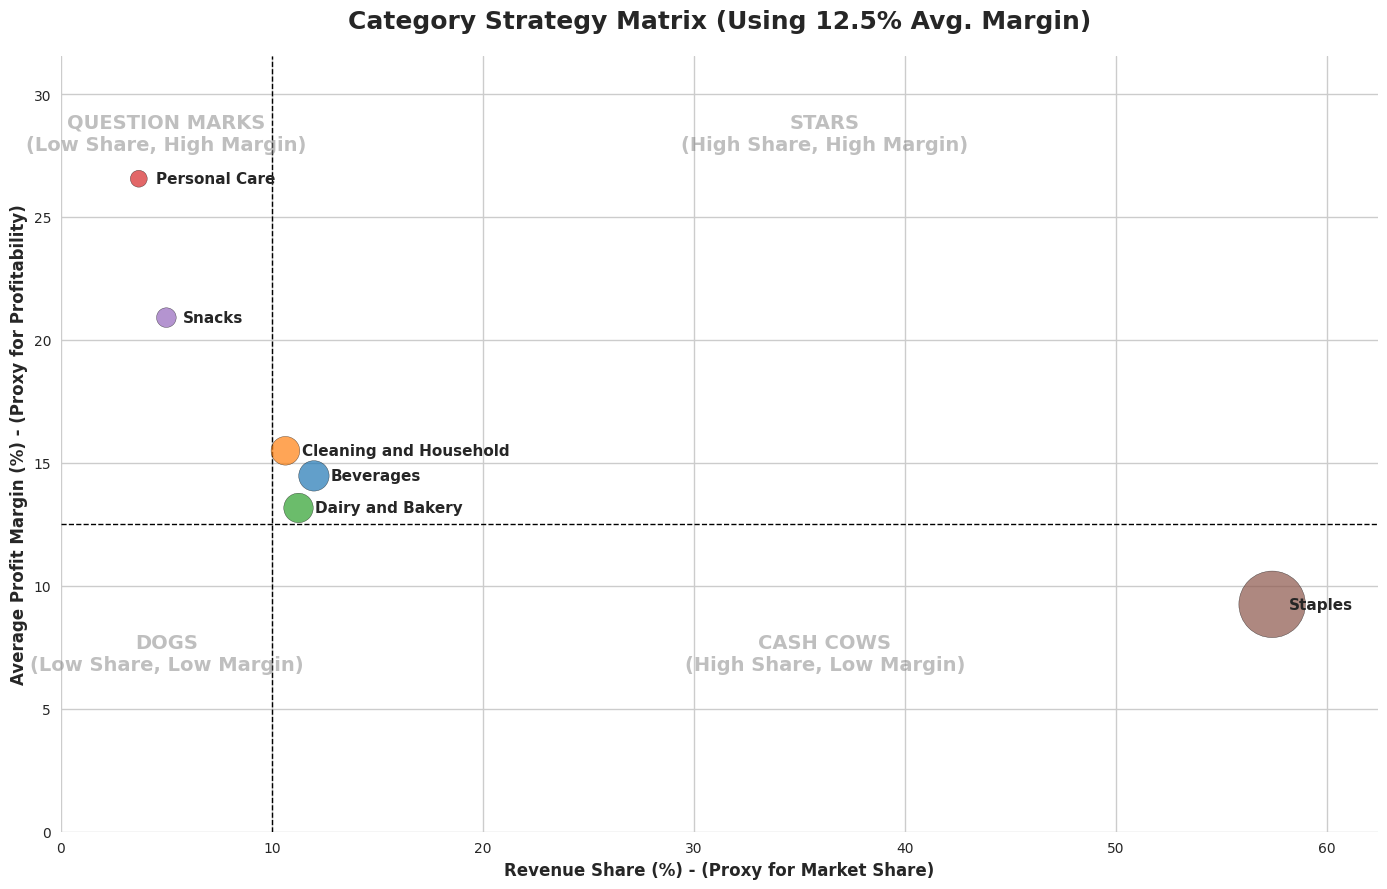


Generating Graph 2: Detailed Monthly Trends (Small Multiples)...
 Graph 2 (Small Multiples) saved as: category_small_multiples_trends.png


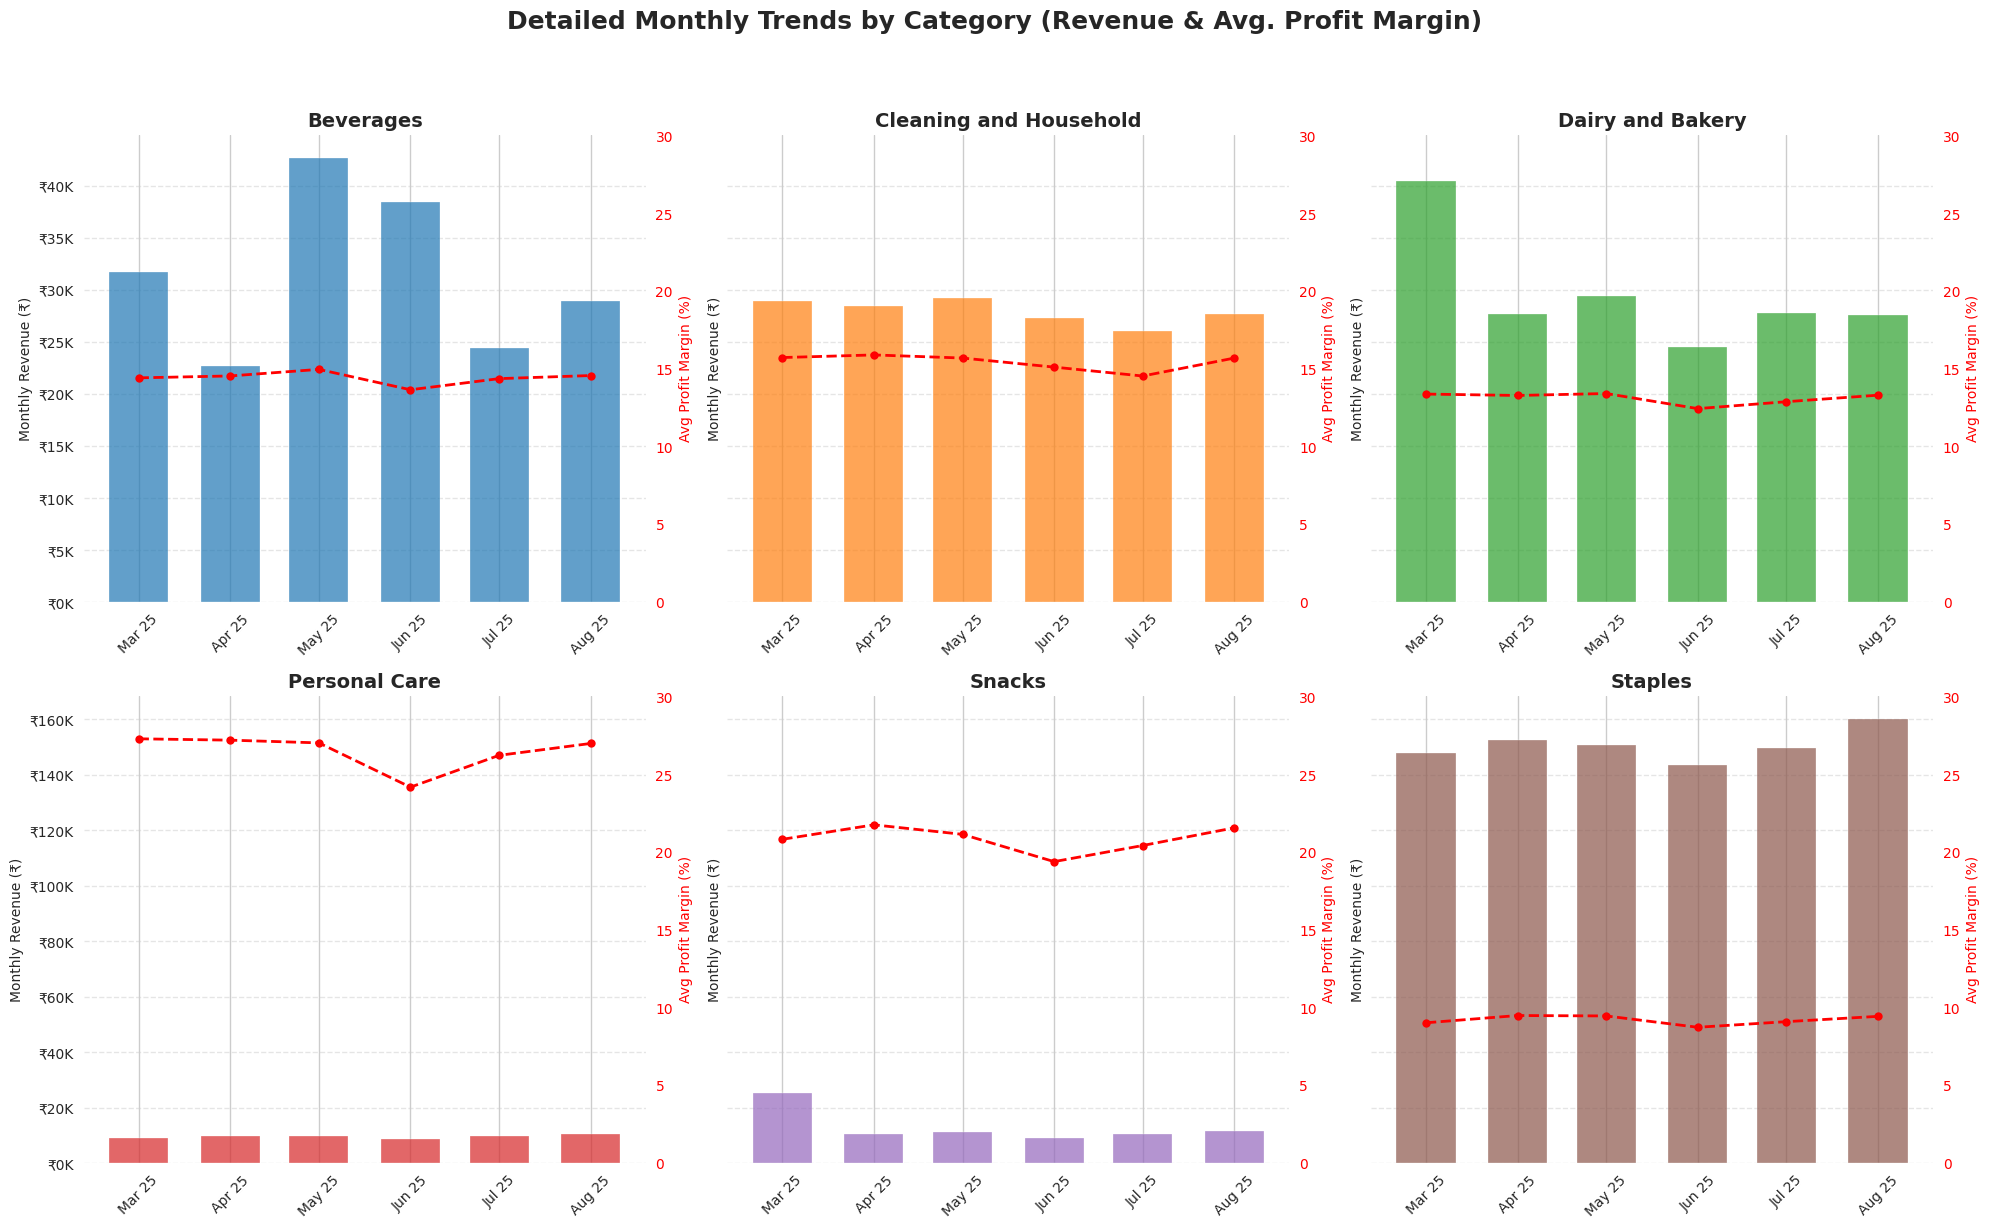


Generating Graph 3: Category Profit Contribution...
 Graph 3 (Profit Contribution) saved as: category_profit_contribution.png


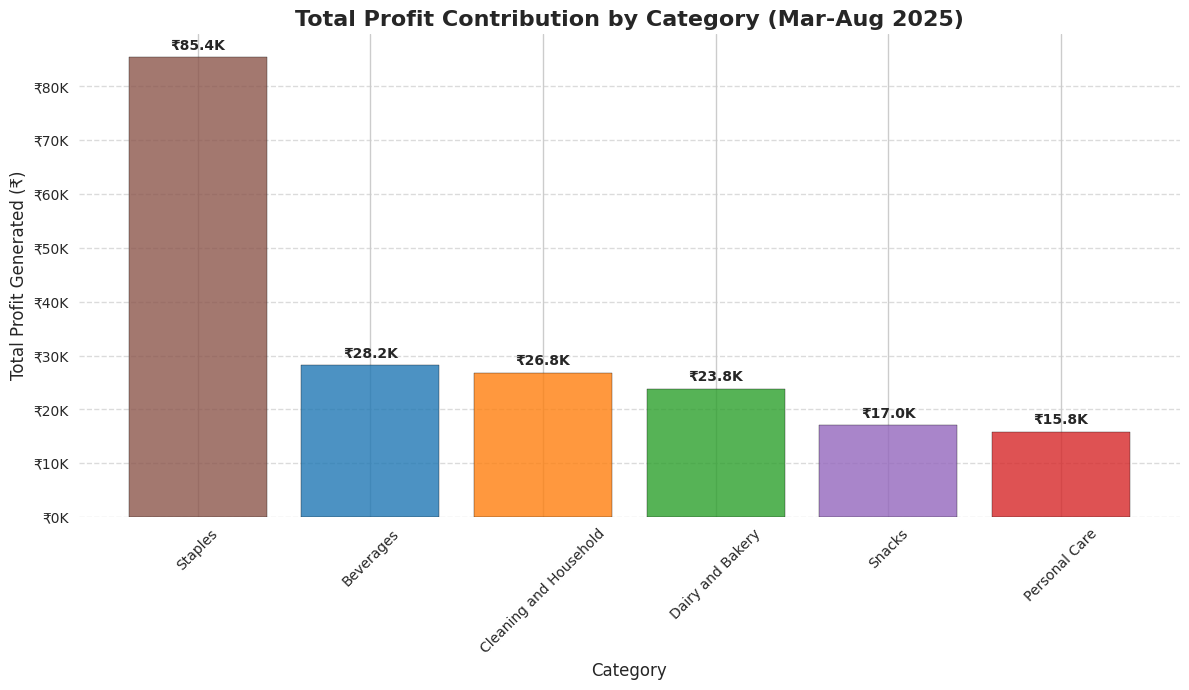

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import auth
import gspread
from google.auth import default
import matplotlib.ticker as mticker
import matplotlib.dates as mdates

# --- 1. Authentication and Data Loading ---
try:
    print("Authenticating...")
    auth.authenticate_user()
    creds, _ = default()
    gc = gspread.authorize(creds)

    # Define sheet and tab names
    SHEET_NAME = 'Faiz General Store -Data'
    TAB_NAME = 'Analysis-Categorywise' # This tab needs Revenue, Profit, Profit_margin, Date, Category

    # Open the sheet and load data
    print(f"Accessing Google Sheet: '{SHEET_NAME}' (Tab: '{TAB_NAME}')...")
    sh = gc.open(SHEET_NAME)
    worksheet = sh.worksheet(TAB_NAME)
    data = worksheet.get_all_records()

    if not data:
        print(" Error: No data found in the worksheet.")
    else:
        df = pd.DataFrame(data)
        print(f" Data loaded successfully with {len(df)} rows.")

        # --- 2. Data Processing ---
        print("\nProcessing data...")
        # Convert columns to appropriate types
        df['Date'] = pd.to_datetime(df['Date'])
        df['Revenue'] = pd.to_numeric(df['Revenue'], errors='coerce').fillna(0)
        df['Profit'] = pd.to_numeric(df['Profit'], errors='coerce').fillna(0)
        df['Profit_margin'] = pd.to_numeric(df['Profit_margin'], errors='coerce').fillna(0)
        df['Category'] = df['Category'].astype(str) # Ensure Category is string

        # Clean category names for consistency
        df['Category'] = df['Category'].apply(lambda x: x.replace('Dairy and\nBakery', 'Dairy & Bakery'))
        df['Category'] = df['Category'].apply(lambda x: x.replace('Cleaning and\nHousehold', 'Cleaning & Household'))

        # Calculate overall metrics needed for BCG
        category_summary = df.groupby('Category').agg(
            Total_Revenue=('Revenue', 'sum'),
            Total_Profit=('Profit', 'sum'),
            Avg_Margin=('Profit_margin', 'mean') # Use mean margin for BCG
        ).reset_index()

        total_revenue_all = category_summary['Total_Revenue'].sum()
        category_summary['Revenue_Share'] = (category_summary['Total_Revenue'] / total_revenue_all) * 100

        # --- 3. Graph 1: BCG-Style Strategy Matrix ---
        print("\nGenerating Graph 1: BCG Matrix...")

        # Prepare data for BCG plot
        x_data = category_summary['Revenue_Share']
        y_data = category_summary['Avg_Margin']
        labels = category_summary['Category']
        size = x_data * 40 # Size based on revenue share

        # Assign a unique color to each category
        colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
        category_color_map = {cat: colors[i % len(colors)] for i, cat in enumerate(labels)}
        plot_colors = [category_color_map.get(cat, '#808080') for cat in labels] # Use map for consistency

        # Define Quadrant Split-Lines
        x_split = 10.0  # Revenue Share threshold
        y_split = 12.5  # Profit Margin threshold (shop's average)

        # Create the Plot
        fig1, ax_bcg = plt.subplots(figsize=(14, 9))
        sns.set_style("whitegrid")

        # Create the scatter (bubble) plot
        ax_bcg.scatter(x_data, y_data, s=size, c=plot_colors, alpha=0.7, edgecolors='black', zorder=2)

        # Add category labels
        for i, txt in enumerate(labels):
             if txt == 'Dairy & Bakery':
                 ax_bcg.text(x_data[i] + 0.8, y_data[i] - 0.5, txt, fontsize=11, fontweight='bold', va='center')
             else:
                 ax_bcg.text(x_data[i] + 0.8, y_data[i], txt, fontsize=11, fontweight='bold', va='center')

        # Add Quadrant Lines and Labels
        ax_bcg.axvline(x=x_split, color='black', linestyle='--', linewidth=1, zorder=1)
        ax_bcg.axhline(y=y_split, color='black', linestyle='--', linewidth=1, zorder=1)

        ax_bcg.set_title('Category Strategy Matrix (Using 12.5% Avg. Margin)', fontsize=18, fontweight='bold', pad=20)
        ax_bcg.set_xlabel('Revenue Share (%) - (Proxy for Market Share)', fontsize=12, fontweight='bold')
        ax_bcg.set_ylabel('Average Profit Margin (%) - (Proxy for Profitability)', fontsize=12, fontweight='bold')

        # Adjust limits and add quadrant text
        x_min, x_max = ax_bcg.get_xlim(); y_min, y_max = ax_bcg.get_ylim()
        x_max_adj = max(x_max, max(x_data)+5) # Ensure space for labels
        y_max_adj = max(y_max, max(y_data)+5)
        x_min_adj = min(x_min, 0) * 0.95
        y_min_adj = min(y_min, 0) * 0.95
        ax_bcg.set_xlim(x_min_adj, x_max_adj)
        ax_bcg.set_ylim(y_min_adj, y_max_adj)

        y_text_top = y_max_adj * 0.9
        y_text_bottom = (y_min_adj + y_split) / 2+1
        ax_bcg.text((x_split + x_max_adj) / 2, y_text_top, 'STARS\n(High Share, High Margin)', ha='center', va='center', fontsize=14, fontweight='bold', color='gray', alpha=0.5)
        ax_bcg.text((x_min_adj + x_split) / 2, y_text_top, 'QUESTION MARKS\n(Low Share, High Margin)', ha='center', va='center', fontsize=14, fontweight='bold', color='gray', alpha=0.5)
        ax_bcg.text((x_split + x_max_adj) / 2, y_text_bottom, 'CASH COWS\n(High Share, Low Margin)', ha='center', va='center', fontsize=14, fontweight='bold', color='gray', alpha=0.5)
        ax_bcg.text((x_min_adj + x_split) / 2, y_text_bottom, 'DOGS\n(Low Share, Low Margin)', ha='center', va='center', fontsize=14, fontweight='bold', color='gray', alpha=0.5)

        plt.tight_layout()
        bcg_filename = 'category_bcg_matrix.png'
        plt.savefig(bcg_filename)
        print(f" Graph 1 (BCG Matrix) saved as: {bcg_filename}")
        plt.show()

        # --- 4. Graph 2: Detailed Monthly Trend Analysis (Small Multiples) ---
        print("\nGenerating Graph 2: Detailed Monthly Trends (Small Multiples)...")

        # Aggregate data: Sum Revenue and Mean Profit Margin per Category per Month
        df['Month'] = df['Date'].dt.to_period('M') # Use Period for correct grouping
        monthly_detailed = df.groupby(['Month', 'Category']).agg(
            Total_Revenue=('Revenue', 'sum'),
            Avg_Profit_Margin=('Profit_margin', 'mean')
        ).reset_index()

        # Convert Period to datetime for plotting compatibility
        monthly_detailed['Month_dt'] = monthly_detailed['Month'].dt.to_timestamp()

        # Get unique categories and colors
        all_categories = sorted(df['Category'].unique()) # Sort for consistent order

        # Create subplots (2 rows, 3 columns)
        fig2, axes = plt.subplots(2, 3, figsize=(20, 12), sharey='row') # Share Y axis for revenue
        axes = axes.ravel() # Flatten

        for i, category in enumerate(all_categories):
            # Filter data for the current category
            category_data = monthly_detailed[monthly_detailed['Category'] == category].sort_values('Month_dt')

            if not category_data.empty:
                # Plot Revenue Bars on primary axis (axes[i])
                axes[i].bar(category_data['Month_dt'], category_data['Total_Revenue'],
                            color=category_color_map.get(category, '#808080'), alpha=0.7, width=20, label='Revenue')

                # Create secondary axis for Profit Margin
                ax2_sm = axes[i].twinx()
                ax2_sm.plot(category_data['Month_dt'], category_data['Avg_Profit_Margin'],
                         color='red', marker='o', linestyle='--', linewidth=2, markersize=6, label='Avg Profit Margin (%)')

                # Formatting for the primary axis (Revenue)
                axes[i].set_title(f'{category}', fontsize=14, fontweight='bold')
                axes[i].set_ylabel('Monthly Revenue (₹)', fontsize=10)
                axes[i].tick_params(axis='x', rotation=45)
                axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'₹{x/1000:.0f}K')) # Format in thousands
                axes[i].grid(True, axis='y', linestyle='--', alpha=0.5)
                axes[i].xaxis.set_major_locator(mdates.MonthLocator(interval=1)) # Ensure ticks are monthly
                axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))

                # Formatting for the secondary axis (Profit Margin)
                ax2_sm.set_ylabel('Avg Profit Margin (%)', fontsize=10, color='red')
                ax2_sm.tick_params(axis='y', labelcolor='red')
                ax2_sm.set_ylim(bottom=0, top=max(monthly_detailed['Avg_Profit_Margin'].max()*1.1, 30)) # Dynamic upper limit
                ax2_sm.grid(False)

            else:
                 axes[i].set_title(f'{category} (No Data)', fontsize=14, fontweight='bold')
                 axes[i].axis('off')

        # Adjust layout for overall figure
        fig2.suptitle('Detailed Monthly Trends by Category (Revenue & Avg. Profit Margin)', fontsize=18, fontweight='bold', y=1.02)
        plt.tight_layout(rect=[0, 0, 1, 0.98])

        # Save the small multiples chart
        small_multiples_filename = 'category_small_multiples_trends.png'
        plt.savefig(small_multiples_filename)
        print(f" Graph 2 (Small Multiples) saved as: {small_multiples_filename}")
        plt.show()

        # --- 5. Graph 3: Category Contribution to Overall Profit (₹) ---
        print("\nGenerating Graph 3: Category Profit Contribution...")

        # Use the category_summary DataFrame calculated earlier
        total_profit_df = category_summary[['Category', 'Total_Profit']].sort_values('Total_Profit', ascending=False)

        # Plotting
        fig3, ax_profit = plt.subplots(figsize=(12, 7))
        palette_profit = sns.color_palette("viridis", len(total_profit_df))

        bars_profit = ax_profit.bar(total_profit_df['Category'], total_profit_df['Total_Profit'],
                                   color=[category_color_map.get(cat, '#808080') for cat in total_profit_df['Category']], # Use consistent colors
                                   alpha=0.8, edgecolor='black')

        ax_profit.set_title('Total Profit Contribution by Category (Mar-Aug 2025)', fontsize=16, fontweight='bold')
        ax_profit.set_xlabel('Category', fontsize=12)
        ax_profit.set_ylabel('Total Profit Generated (₹)', fontsize=12)
        ax_profit.tick_params(axis='x', rotation=45, labelsize=10, labelrotation=45, labelright=False) # Rotate x-axis labels
        ax_profit.grid(axis='y', linestyle='--', alpha=0.7)
        ax_profit.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'₹{x/1000:.0f}K')) # Format Y-axis in thousands

        # Add data labels on top of bars
        for bar in bars_profit:
            height = bar.get_height()
            if height > 0:
                ax_profit.text(bar.get_x() + bar.get_width() / 2., height + max(total_profit_df['Total_Profit'])*0.01, # Adjusting y-pos slightly based on max height
                         f'₹{height/1000:.1f}K',
                         ha='center', va='bottom', fontsize=10, fontweight='bold')

        plt.tight_layout()

        # Save the chart
        profit_contribution_filename = 'category_profit_contribution.png'
        plt.savefig(profit_contribution_filename)
        print(f" Graph 3 (Profit Contribution) saved as: {profit_contribution_filename}")
        plt.show()


except gspread.exceptions.SpreadsheetNotFound:
    print(f"\n--- ERROR ---")
    print(f"Spreadsheet named '{SHEET_NAME}' not found.")
except gspread.exceptions.WorksheetNotFound:
    print(f"\n--- ERROR ---")
    print(f"Worksheet named '{TAB_NAME}' not found.")
except Exception as e:
    print(f"\n--- AN ERROR OCCURRED ---")
    print(e)
    print("\n--- TROUBLESHOOTING ---")
    print("1. Did you grant Google Colab access to your Google account?")
    print("2. Check for typos in SHEET_NAME and TAB_NAME.")
    print("4. Check column names ('Date', 'Category', 'Revenue', 'Profit', 'Profit_margin').")

In [ ]:
print("\n--- MONTHLY DATA VERIFICATION FOR SMALL MULTIPLES GRAPH ---")

if 'monthly_detailed' not in locals():
    df['Month'] = df['Date'].dt.to_period('M')
    monthly_detailed = df.groupby(['Month', 'Category']).agg(
        Total_Revenue=('Revenue', 'sum'),
        Avg_Profit_Margin=('Profit_margin', 'mean')
    ).reset_index()
    monthly_detailed['Month_dt'] = monthly_detailed['Month'].dt.to_timestamp()

# Format Month column for better display
monthly_detailed['Month_Formatted'] = monthly_detailed['Month_dt'].dt.strftime('%b %Y')

# Category-wise detailed data display
categories = sorted(monthly_detailed['Category'].unique())

for category in categories:
    print(f"\n{'='*60}")
    print(f"CATEGORY: {category}")
    print(f"{'='*60}")

    cat_data = monthly_detailed[monthly_detailed['Category'] == category].sort_values('Month_dt')

    if not cat_data.empty:
        print(f"{'Month':<12} {'Revenue (₹)':<15} {'Avg Margin (%)':<15}")
        print(f"{'-'*45}")

        total_revenue = 0
        for _, row in cat_data.iterrows():
            revenue = row['Total_Revenue']
            margin = row['Avg_Profit_Margin']
            total_revenue += revenue

            print(f"{row['Month_Formatted']:<12} ₹{revenue:>10,.0f}   {margin:>12.2f}%")

        # Category summary
        avg_margin = cat_data['Avg_Profit_Margin'].mean()
        print(f"{'-'*45}")
        print(f"{'TOTAL/AVG':<12} ₹{total_revenue:>10,.0f}   {avg_margin:>12.2f}%")
    else:
        print("No data available for this category")

# Overall summary table
print(f"\n{'='*80}")
print("OVERALL MONTHLY SUMMARY (All Categories Combined)")
print(f"{'='*80}")

# Calculate monthly totals across all categories
monthly_summary = monthly_detailed.groupby('Month_Formatted').agg(
    Total_Monthly_Revenue=('Total_Revenue', 'sum'),
    Weighted_Avg_Margin=('Avg_Profit_Margin', 'mean')  # Simple average for overall
).reset_index()

print(f"{'Month':<12} {'Total Revenue (₹)':<20} {'Avg Margin (%)':<15}")
print(f"{'-'*50}")

grand_total = 0
for _, row in monthly_summary.iterrows():
    revenue = row['Total_Monthly_Revenue']
    margin = row['Weighted_Avg_Margin']
    grand_total += revenue

    print(f"{row['Month_Formatted']:<12} ₹{revenue:>15,.0f}   {margin:>12.2f}%")

print(f"{'-'*50}")
print(f"{'GRAND TOTAL':<12} ₹{grand_total:>15,.0f}")

# Additional verification - cross-check with BCG matrix data
print(f"\n{'='*80}")
print("CROSS-VERIFICATION WITH BCG MATRIX DATA")
print(f"{'='*80}")

print("\nCategory-wise totals from monthly data (should match BCG matrix):")
category_totals_from_monthly = monthly_detailed.groupby('Category').agg(
    Calculated_Total_Revenue=('Total_Revenue', 'sum'),
    Calculated_Avg_Margin=('Avg_Profit_Margin', 'mean')
).reset_index()

# Merge with original BCG data for comparison
verification_df = category_summary.merge(category_totals_from_monthly, on='Category')

print(f"\n{'Category':<25} {'BCG Revenue':<12} {'Monthly Revenue':<15} {'BCG Margin':<10} {'Monthly Margin':<12}")
print(f"{'-'*80}")
for _, row in verification_df.iterrows():
    print(f"{row['Category']:<25} ₹{row['Total_Revenue']:>9,.0f}   ₹{row['Calculated_Total_Revenue']:>12,.0f}   {row['Avg_Margin']:>8.2f}%   {row['Calculated_Avg_Margin']:>10.2f}%")

# Data quality check
print(f"\n{'='*80}")
print("DATA QUALITY CHECK")
print(f"{'='*80}")

# Check for missing months in any category
all_months = sorted(monthly_detailed['Month'].unique())
all_categories = monthly_detailed['Category'].unique()

print(f"\nTotal months in dataset: {len(all_months)}")
print(f"Total categories: {len(all_categories)}")
print(f"Expected monthly records: {len(all_months) * len(all_categories)}")
print(f"Actual monthly records: {len(monthly_detailed)}")

# Find categories with missing months
for category in all_categories:
    cat_months = monthly_detailed[monthly_detailed['Category'] == category]['Month'].unique()
    missing_months = set(all_months) - set(cat_months)
    if missing_months:
        print(f" {category}: Missing {len(missing_months)} months")

print(f"\nVerification complete! All data is now available for cross-checking.")


--- MONTHLY DATA VERIFICATION FOR SMALL MULTIPLES GRAPH ---

CATEGORY: Beverages
Month        Revenue (₹)     Avg Margin (%) 
---------------------------------------------
Mar 2025     ₹    31,776          14.47%
Apr 2025     ₹    22,670          14.59%
May 2025     ₹    42,722          15.01%
Jun 2025     ₹    38,428          13.70%
Jul 2025     ₹    24,479          14.42%
Aug 2025     ₹    28,983          14.62%
---------------------------------------------
TOTAL/AVG    ₹   189,058          14.47%

CATEGORY: Cleaning and Household
Month        Revenue (₹)     Avg Margin (%) 
---------------------------------------------
Mar 2025     ₹    28,970          15.78%
Apr 2025     ₹    28,500          15.94%
May 2025     ₹    29,261          15.74%
Jun 2025     ₹    27,286          15.16%
Jul 2025     ₹    26,092          14.59%
Aug 2025     ₹    27,656          15.74%
---------------------------------------------
TOTAL/AVG    ₹   167,765          15.49%

CATEGORY: Dairy and Bakery
Month   

## **Financial Health Analysis**




Starting Financial Health Analysis using Analysis-Daywise data...
Analysis-Daywise data loaded successfully!
Date range: 2024-09-01 to 2025-08-31

GRAPH 1: Cash-to-Credit Ratio Trend Analysis (with Shaded Zones)


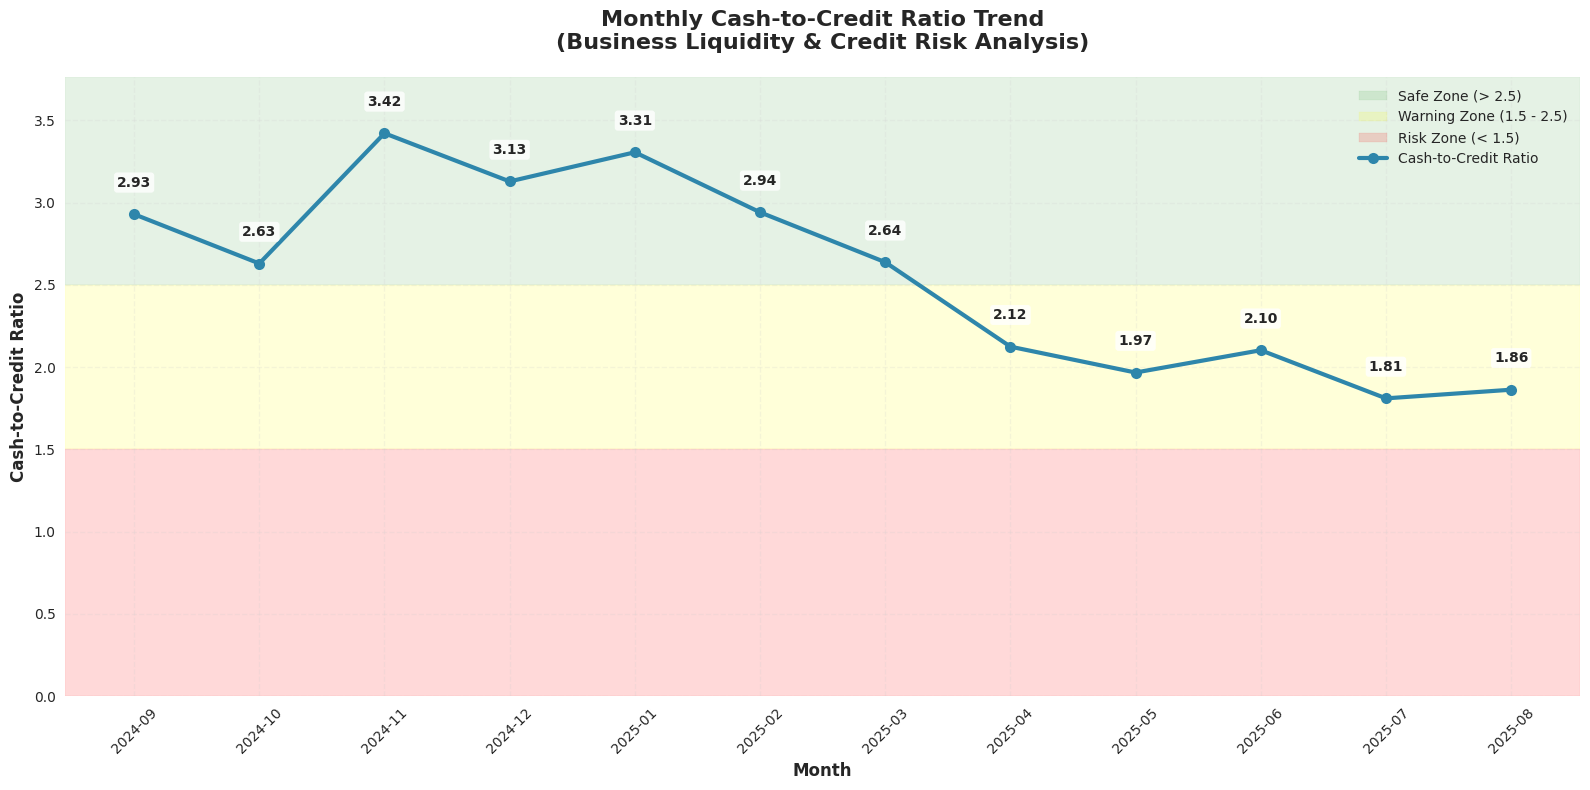


GRAPH 2: Revenue & Profitability Trend Analysis


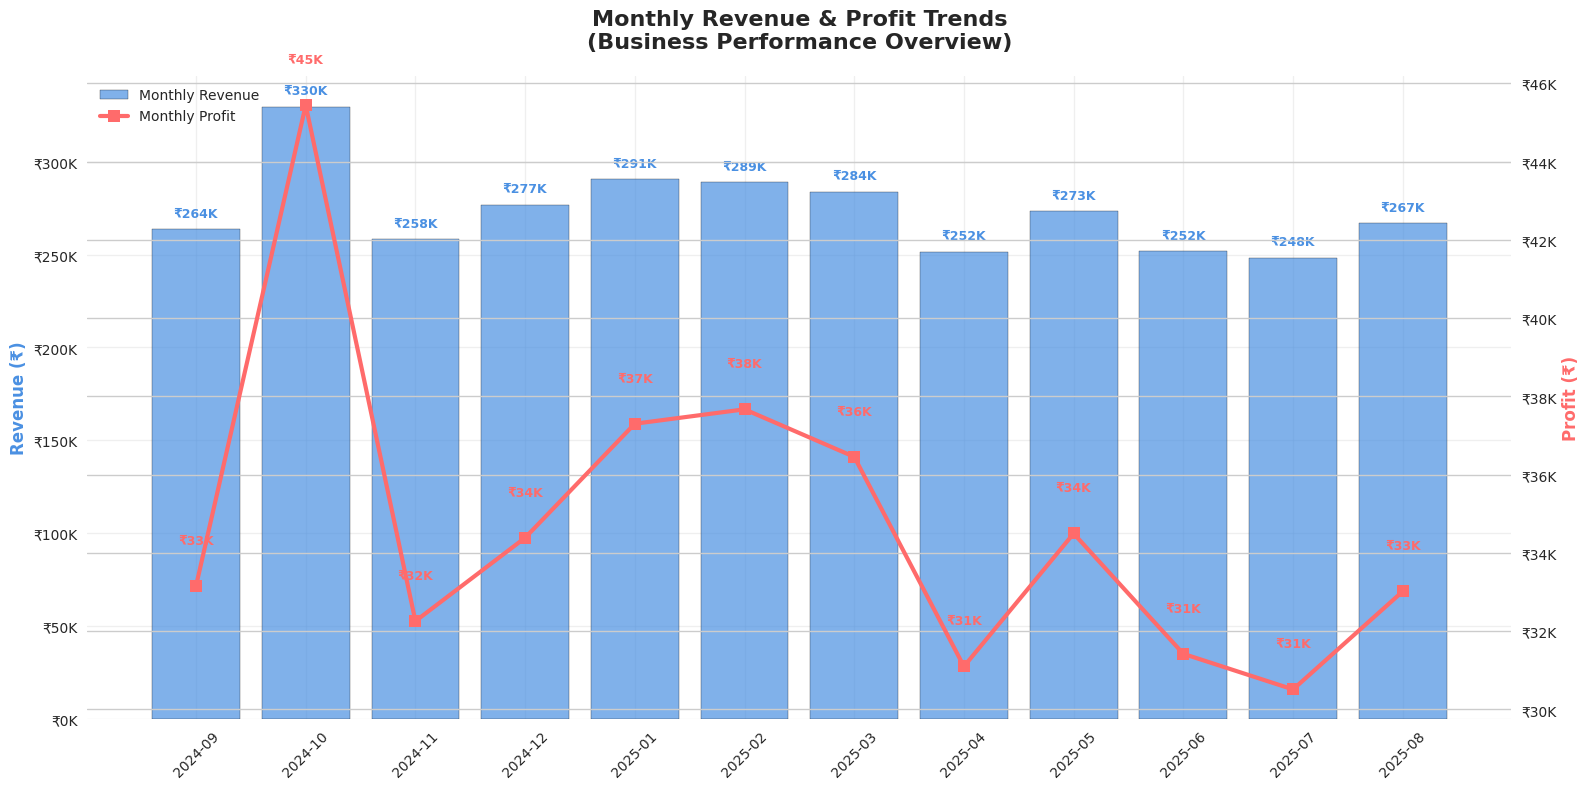


GRAPH 3: Weekly Revenue Trend Analysis


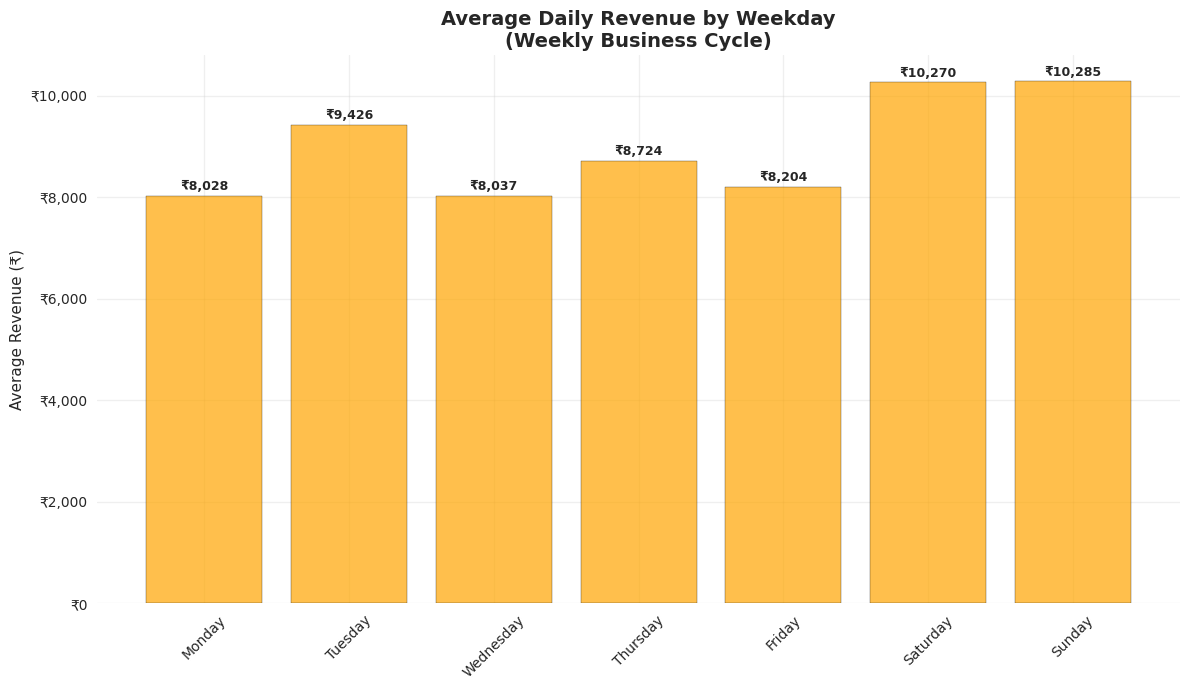


FINANCIAL HEALTH ANALYSIS COMPLETED!
   3 Focused Graphs Generated.


In [ ]:
# =============================================================================
# FINANCIAL HEALTH ANALYSIS - USING Analysis-Daywise data (FOCUSED)
# =============================================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.ticker as mticker
import matplotlib.dates as mdates

# --- Google Colab Libraries ---
try:
    from google.colab import auth
    from google.auth import default
    import gspread
except ImportError:
    print("Warning: Google Colab libraries not found. Data loading will fail if not in Colab.")
    # Defining dummy classes if not in Colab to avoid NameErrors
    class Auth:
        def authenticate_user(self): pass
    auth = Auth()
    class Default:
        def __call__(self): return (None, None)
    default = Default()
    class Gspread:
        def authorize(self, creds): return self
        def open(self, name): raise Exception("Not in Colab")
    gspread = Gspread()
# --- End of Colab setup ---


print("Starting Financial Health Analysis using Analysis-Daywise data...")

# Loading the day-wise data from my correct tab
def load_daywise_data_correct():
    """Load day-wise financial data from Analysis-Daywise tab"""
    try:
        auth.authenticate_user()
        creds, _ = default()
        gc = gspread.authorize(creds)

        spreadsheet = gc.open('Faiz General Store -Data')
        worksheet = spreadsheet.worksheet('Analysis-Daywise')

        daywise_df = pd.DataFrame(worksheet.get_all_records())

        # Converting date column to datetime
        daywise_df['Date'] = pd.to_datetime(daywise_df['Date'])

        # Converting numeric columns
        numeric_columns = ['Revenue', 'Cash_Sale', 'Credit_Sale', 'Cost', 'Profit', 'Profit_margin', 'Cash_to_Credit_ratio']
        for col in numeric_columns:
            daywise_df[col] = pd.to_numeric(daywise_df[col], errors='coerce')

        print("Analysis-Daywise data loaded successfully!")
        print(f"Date range: {daywise_df['Date'].min().strftime('%Y-%m-%d')} to {daywise_df['Date'].max().strftime('%Y-%m-%d')}")
        return daywise_df

    except Exception as e:
        print(f"Error loading Analysis-Daywise data: {e}")
        return None

# Loading the data
daywise_df = load_daywise_data_correct()

if daywise_df is None:
    print("Could not load data. Please check the tab name and permissions.")
    raise Exception("Data loading failed")

# --- Pre-calculating Monthly Averages (used by Graph 1 & 2) ---
monthly_data = daywise_df.copy()
monthly_data['YearMonth'] = monthly_data['Date'].dt.to_period('M')
monthly_avg = monthly_data.groupby('YearMonth').agg({
    'Cash_to_Credit_ratio': 'mean',
    'Revenue': 'sum',
    'Cash_Sale': 'sum',
    'Credit_Sale': 'sum',
    'Profit': 'sum'
}).reset_index()
monthly_avg['YearMonth'] = monthly_avg['YearMonth'].astype(str)

# =============================================================================
# GRAPH 1: CASH-TO-CREDIT RATIO TREND ANALYSIS (FOCUSED & ENHANCED)
# =============================================================================

print("\n" + "="*60)
print("GRAPH 1: Cash-to-Credit Ratio Trend Analysis (with Shaded Zones)")
print("="*60)

fig, ax1 = plt.subplots(figsize=(16, 8)) # Create a single plot

# ---  ENHANCEMENT: Using Shaded Zones  ---
ax1.set_ylim(bottom=0, top=max(monthly_avg['Cash_to_Credit_ratio'].max() * 1.1, 3.0))
y_min, y_max = ax1.get_ylim()

# Adding shaded risk zones wich will make my graph most professional looking
ax1.axhspan(2.5, y_max, color='green', alpha=0.1, zorder=0, label='Safe Zone (> 2.5)')
ax1.axhspan(1.5, 2.5, color='yellow', alpha=0.15, zorder=0, label='Warning Zone (1.5 - 2.5)')
ax1.axhspan(y_min, 1.5, color='red', alpha=0.15, zorder=0, label='Risk Zone (< 1.5)')

# Creating the trend line
ax1.plot(monthly_avg['YearMonth'], monthly_avg['Cash_to_Credit_ratio'],
         marker='o', linewidth=3, markersize=8, color='#2E86AB',
         label='Cash-to-Credit Ratio', zorder=5)
# ---  END OF ENHANCEMENT  ---

# Adding value labels for significant points
for i, (month, ratio) in enumerate(zip(monthly_avg['YearMonth'], monthly_avg['Cash_to_Credit_ratio'])):
    ax1.text(i, ratio + 0.15, f'{ratio:.2f}', ha='center', va='bottom',
             fontsize=10, fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.8), zorder=6)

ax1.set_title('Monthly Cash-to-Credit Ratio Trend\n(Business Liquidity & Credit Risk Analysis)',
              fontsize=16, fontweight='bold', pad=20)
ax1.set_ylabel('Cash-to-Credit Ratio', fontsize=12, fontweight='bold')
ax1.set_xlabel('Month', fontsize=12, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.2, linestyle='--') # Making grid lighter

# Highlighting critical months
critical_months = monthly_avg[monthly_avg['Cash_to_Credit_ratio'] < 1.5]
for _, row in critical_months.iterrows():
    idx = monthly_avg[monthly_avg['YearMonth'] == row['YearMonth']].index[0]
    ax1.annotate('RISK', xy=(idx, row['Cash_to_Credit_ratio']),
                 xytext=(idx, row['Cash_to_Credit_ratio'] - 0.5),
                 arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
                 fontsize=10, fontweight='bold', color='red',
                 bbox=dict(boxstyle="round,pad=0.3", facecolor='yellow', alpha=0.8), zorder=6)

plt.tight_layout()
plt.show()



# =============================================================================
# GRAPH 2: REVENUE & PROFITABILITY TREND ANALYSIS
# =============================================================================

print("\n" + "="*60)
print("GRAPH 2: Revenue & Profitability Trend Analysis")
print("="*60)

# --- This figure now only has ONE plot (ax1) ---
fig, ax1 = plt.subplots(figsize=(16, 8)) # Changed from (2,1)

# Plot 1: Monthly Revenue and Profit Trends
months = monthly_avg['YearMonth']
revenue = monthly_avg['Revenue']
profit = monthly_avg['Profit']

# Bar chart for revenue with profit overlay
bars = ax1.bar(months, revenue, color='#4A90E2', alpha=0.7, label='Monthly Revenue', edgecolor='black')

# Add profit as line on a secondary axis
ax1_twin = ax1.twinx()
profit_line = ax1_twin.plot(months, profit, color='#FF6B6B', linewidth=3,
                            marker='s', markersize=8, label='Monthly Profit')

ax1.set_title('Monthly Revenue & Profit Trends\n(Business Performance Overview)',
              fontsize=16, fontweight='bold', pad=20)
ax1.set_ylabel('Revenue (₹)', fontsize=12, fontweight='bold', color='#4A90E2')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₹{x/1000:.0f}K'))

ax1_twin.set_ylabel('Profit (₹)', fontsize=12, fontweight='bold', color='#FF6B6B')
ax1_twin.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₹{x/1000:.0f}K'))

# Combine legends for the dual-axis chart
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

# Add revenue value labels
for bar, rev in zip(bars, revenue):
    if rev > 150000:
        ax1.text(bar.get_x() + bar.get_width()/2., rev + 5000,
                 f'₹{rev/1000:.0f}K', ha='center', va='bottom',
                 fontsize=9, fontweight='bold', color='#4A90E2')

# Add profit value labels
for i, (month, prof) in enumerate(zip(months, profit)):
    if prof > 15000:
        ax1_twin.text(i, prof + 1000, f'₹{prof/1000:.0f}K',
                      ha='center', va='bottom', fontsize=9, fontweight='bold', color='#FF6B6B')

plt.tight_layout()
plt.show()



# =============================================================================
# GRAPH 3: WEEKLY REVENUE TREND ANALYSIS
# =============================================================================

print("\n" + "="*60)
print("GRAPH 3: Weekly Revenue Trend Analysis")
print("="*60)

# Analyze seasonal patterns
daywise_df['DayOfWeek'] = daywise_df['Date'].dt.day_name()

weekly_patterns = daywise_df.groupby('DayOfWeek').agg({
    'Revenue': 'mean',
}).reset_index()

# Order days of week properly
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekly_patterns['DayOfWeek'] = pd.Categorical(weekly_patterns['DayOfWeek'], categories=day_order, ordered=True)
weekly_patterns = weekly_patterns.sort_values('DayOfWeek')

# --- This figure now has ONE plot ---
fig, ax1 = plt.subplots(figsize=(12, 7)) # Changed layout

# Plot 1: Weekly Revenue Pattern
bars = ax1.bar(weekly_patterns['DayOfWeek'], weekly_patterns['Revenue'], color='orange', alpha=0.7, edgecolor='black')
ax1.set_title('Average Daily Revenue by Weekday\n(Weekly Business Cycle)',
              fontsize=14, fontweight='bold')
ax1.set_ylabel('Average Revenue (₹)', fontsize=11)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₹{x:,.0f}'))

for bar, revenue_val in zip(bars, weekly_patterns['Revenue']):
    ax1.text(bar.get_x() + bar.get_width()/2., revenue_val + 50,
             f'₹{revenue_val:,.0f}', ha='center', va='bottom',
             fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()



print("\nFINANCIAL HEALTH ANALYSIS COMPLETED!")
print(f"   3 Focused Graphs Generated.")

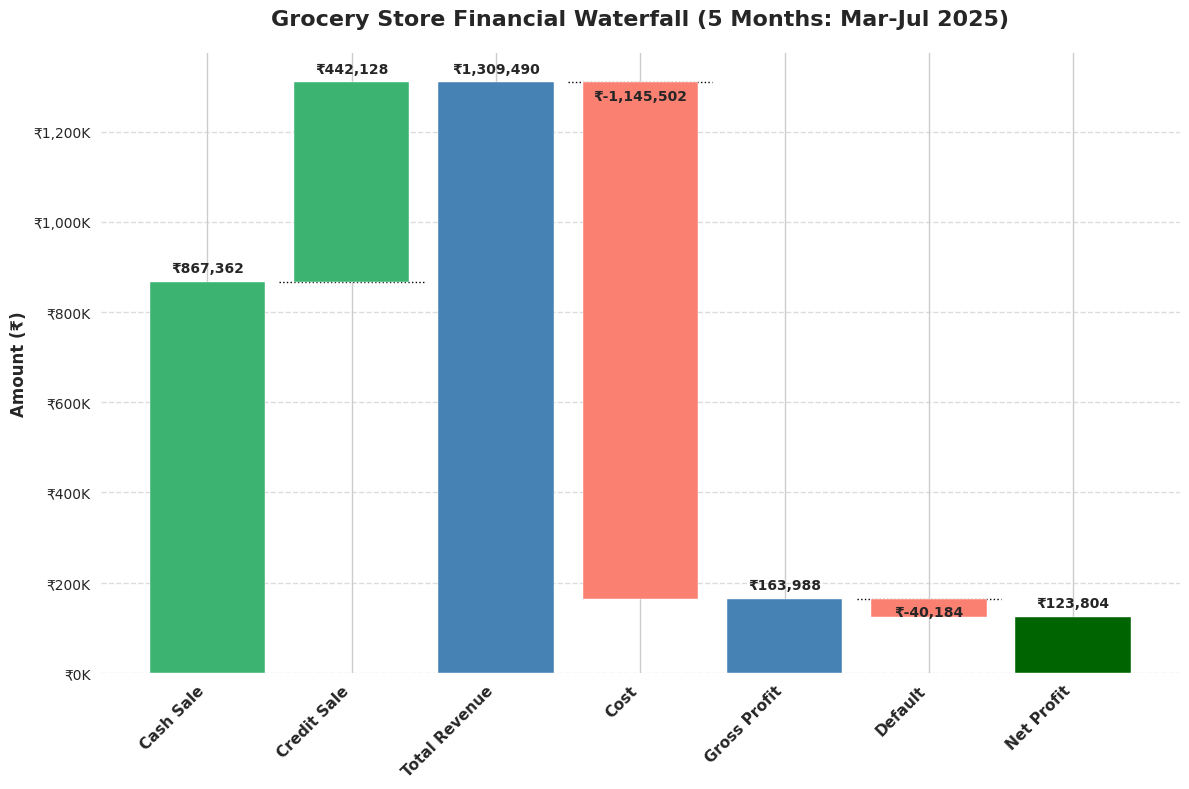

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as mticker

# 1. My Data, which i summarised from my gsheet
labels = ['Cash Sale', 'Credit Sale', 'Total Revenue', 'Cost', 'Gross Profit', 'Default', 'Net Profit']
data = np.array([867362, 442128, 1309490, -1145502, 163988, -40184, 123804])
is_total = [False, False, True, False, True, False, True] # Mark totals

# 2. Preparing for waterfall chart
level = 0
bottoms = []
heights = []
for i, val in enumerate(data):
    if is_total[i]:
        bottoms.append(0)
        heights.append(val)
    else:
        bottoms.append(level)
        heights.append(val)
    if not is_total[i]:
        level += val

# 3. Now chart making time
fig, ax = plt.subplots(figsize=(12, 8))
x_pos = np.arange(len(labels))


colors = []
for i, val in enumerate(data):
    if labels[i] == 'Net Profit':
        if val > 0:
            colors.append('darkgreen') # Darker green for a strong positive Net Profit
        else:
            colors.append('darkred')   # Darker red for negative Net Profit (shouldn't happen here)
    elif labels[i] == 'Total Revenue' or labels[i] == 'Gross Profit':
        colors.append('steelblue') # A clear blue for intermediate totals
    elif val > 0:
        colors.append('mediumseagreen') # Lighter green for positive contributions
    else: # Cost or Default
        colors.append('salmon') # A distinct red/orange for negative impacts (Cost, Default)

# Plot bars
bars = ax.bar(x_pos, heights, bottom=bottoms, color=colors, zorder=3)


for i in range(1, len(bottoms)):
     if not is_total[i]:
         prev_end = bottoms[i-1] + heights[i-1] if not is_total[i-1] else heights[i-1]
         if abs(prev_end - bottoms[i]) < 1:
              ax.plot([i-0.5, i+0.5], [bottoms[i], bottoms[i]], 'k:', linewidth=1, zorder=2)


# 5. Adding Data lables
for i, bar in enumerate(bars):
    val = data[i]
    y_pos = bar.get_y() + bar.get_height()
    va = 'bottom'
    offset = 15000 # Increased offset slightly for labels

    if not is_total[i] and val < 0:
        y_pos = bar.get_y()
        va = 'top'
        offset = -15000
    elif is_total[i] and val < 0:
         y_pos = bar.get_height()
         va = 'top'
         offset = -15000
    elif is_total[i] and val > 0:
         y_pos = bar.get_height()
         va = 'bottom'
         offset = 15000


    ax.text(bar.get_x() + bar.get_width() / 2, y_pos + offset, f'₹{val:,.0f}',
            ha='center', va=va, fontweight='bold', fontsize=10)

# 6. customising the chart for best capstone report
ax.set_xticks(x_pos)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=11, fontweight='bold') # Made x-labels bold
ax.set_ylabel('Amount (₹)', fontsize=12, fontweight='bold')

ax.set_title('Grocery Store Financial Waterfall (5 Months: Mar-Jul 2025)',
             fontsize=16, fontweight='bold', pad=20)

ax.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'₹{x/1000:,.0f}K'))

current_ylim = ax.get_ylim()
ax.set_ylim(current_ylim[0], current_ylim[1] * 1.05)

plt.tight_layout()
plt.show()